### <span style = "color:orange">1. Introduction<span>

#### <span style="color:green">1.1. Project purpose</span>

Xây dựng và đánh giá tập hợp các mô hình dự báo chuỗi thời gian để dự đoán nhiệt độ cực đại hàng ngày tại các khu vực đô thị và ven biển Việt Nam. Dự án áp dụng cả thuật toán Machine Learning truyền thống và Deep Learning hiện đại nhằm cải thiện độ chính xác dự báo so với các phương pháp thống kê thông thường.

<b>Nguồn dữ liệu</b>: Bộ dữ liệu ERA5 (ECMWF) với các bản ghi nhiệt độ từ 1990 đến 2024, được xử lý và biến đổi để huấn luyện các mô hình như Random Forest, XGBoost, LSTM, Transformer, TFT, và N-BEATS.

<b>Kết quả</b>: Đánh giá hiệu năng giữa các mô hình qua nhiều kịch bản thực nghiệm và đề xuất hệ thống cảnh báo nhiệt độ sớm ứng dụng thực tế.

#### <span style="color:green">1.2. Data source and description</span>

<h4>Thông tin dữ liệu trong đề tài:</h4>

<ul>
<li><b>Thời gian thu thập:</b> từ năm <b>1990 đến 2024</b></li>
<li><b>Định dạng ban đầu:</b> .grib, sau đó chuyển đổi sang .csv để xử lý</li>
</ul>

<h4>Các biến số chính trong tập dữ liệu:</h4>

<table>
<thead>
<tr>
<th>Tên cột dữ liệu</th>
<th>Ý nghĩa</th>
<th>Đơn vị đo</th>
</tr>
</thead>
<tbody>
<tr><td><code>NAME</code></td><td>Tên tỉnh/thành phố nơi thu thập dữ liệu</td><td>-</td></tr>
<tr><td><code>LATITUDE</code></td><td>Vĩ độ địa lý của điểm đo</td><td>Độ</td></tr>
<tr><td><code>LONGITUDE</code></td><td>Kinh độ địa lý của điểm đo</td><td>Độ</td></tr>
<tr><td><code>YMD</code></td><td>Ngày/tháng/năm đo đạc</td><td>dd/mm/yyyy</td></tr>
<tr><td><code>YEAR</code></td><td>Năm đo đạc</td><td>Năm</td></tr>
<tr><td><code>MONTH</code></td><td>Tháng đo đạc</td><td>Tháng</td></tr>
<tr><td><code>DAY</code></td><td>Ngày đo đạc</td><td>Ngày</td></tr>
<tr><td><code>TEMP_max</code></td><td>Nhiệt độ không khí cực đại trong ngày</td><td>°C</td></tr>
<tr><td><code>TEMP_ave</code></td><td>Nhiệt độ trung bình trong ngày</td><td>°C</td></tr>
<tr><td><code>DEW_ave</code></td><td>Điểm sương trung bình trong ngày</td><td>°C</td></tr>
<tr><td><code>DEW_max</code></td><td>Điểm sương cao nhất trong ngày</td><td>°C</td></tr>
<tr><td><code>RH_ave</code></td><td>Độ ẩm tương đối trung bình trong ngày</td><td>%</td></tr>
<tr><td><code>RH_max</code></td><td>Độ ẩm tương đối cực đại trong ngày</td><td>%</td></tr>
<tr><td><code>AT_ave</code></td><td>Nhiệt độ cảm nhận trung bình trong ngày (Apparent Temp.)</td><td>°C</td></tr>
<tr><td><code>AT_max</code></td><td>Nhiệt độ cảm nhận cao nhất trong ngày</td><td>°C</td></tr>
<tr><td><code>SP_ave</code></td><td>Áp suất bề mặt trung bình trong ngày (Surface Pressure)</td><td>hPa</td></tr>
<tr><td><code>TCC_avg</code></td><td>Lượng mây che phủ trung bình trong ngày (Total Cloud Cover)</td><td>%</td></tr>
<tr><td><code>TP_sum</code></td><td>Lượng mưa tích lũy trong ngày (Total Precipitation)</td><td>mm</td></tr>
<tr><td><code>WIND_speed_avg</code></td><td>Tốc độ gió trung bình trong ngày</td><td>m/s</td></tr>
<tr><td><code>WIND_direction_deg_avg</code></td><td>Hướng gió trung bình trong ngày</td><td>Độ (0°–360°)</td></tr>
</tbody>
</table>


<p><b>Biến mục tiêu chính:</b></p>
<ul>
<li><code>TEMP_max</code> — Nhiệt độ không khí cực đại hàng ngày (°C)</li>
</ul>

<p><b>Lưu ý:</b> Dữ liệu gốc của ERA5 có thể chứa giá trị thiếu, giá trị ngoại lai và một số dị bản khí tượng đặc thù. Do đó, quá trình làm sạch dữ liệu, xử lý giá trị thiếu, phát hiện ngoại lệ và chuẩn hóa dữ liệu là các bước bắt buộc trước khi tiến hành huấn luyện và dự báo.</p>

In [1]:
match_type = {
    'NAME'       : 'Categorical',  # Tên tỉnh/thành phố (chuỗi)
    'LATITUDE'   : 'Numerical',    # Vĩ độ (°)
    'LONGITUDE'  : 'Numerical',    # Kinh độ (°)
    'YMD'        : 'Datetime',     # Ngày/tháng/năm (dd/mm/yyyy)
    'YEAR'       : 'Numerical',    # Năm (năm)
    'MONTH'      : 'Numerical',    # Tháng (1-12)
    'DAY'        : 'Numerical',    # Ngày (1-31)

    'TEMP_max'   : 'Numerical',    # Nhiệt độ cực đại trong ngày (°C)
    'TEMP_ave'   : 'Numerical',    # Nhiệt độ trung bình trong ngày (°C)
    'DEW_ave'    : 'Numerical',    # Điểm sương trung bình trong ngày (°C)
    'DEW_max'    : 'Numerical',    # Điểm sương cực đại trong ngày (°C)
    'RH_ave'     : 'Numerical',    # Độ ẩm tương đối trung bình trong ngày (%)
    'RH_max'     : 'Numerical',    # Độ ẩm tương đối cực đại trong ngày (%)
    'AT_ave'     : 'Numerical',    # Nhiệt độ cảm nhận trung bình trong ngày (°C)
    'AT_max'     : 'Numerical',    # Nhiệt độ cảm nhận cực đại trong ngày (°C)

    'SP_ave'              : 'Numerical',  # Áp suất bề mặt trung bình trong ngày (kPa)
    'TCC_avg'             : 'Numerical',  # Lượng mây che phủ trung bình trong ngày (%)
    'TP_sum'              : 'Numerical',  # Lượng mưa tích lũy trong ngày (mm)
    'WIND_speed_avg'      : 'Numerical',  # Tốc độ gió trung bình trong ngày (m/s)
    'WIND_direction_deg_avg' : 'Numerical'  # Hướng gió trung bình trong ngày (0°–360°)
}

#### <span style="color:green">1.3. Goals</span>

<img src="../../image/Ảnh chụp màn hình 2025-06-24 210616.png">

<img src="../../image/image.png" width="1000px">

### <span style="color:orange">2. Import Libraries</span>

#### <span style="color:green">2.1. Configuration and display settings</span>

In [2]:
import sys
sys.path.append("../")  # đường dẫn đến thư mục chứa src

from src.utilities import(config, 
                          dataset, 
                          features, 
                          plots)

from src.models import(anomaly_models,
                       forecasting_models,
                       model_utils)

from scripts import(evaluate_model,
                    run_forecast,
                    train_model)

In [3]:
PROJ_SEED  = config.getSeed()

# Cấu hình cho nhiều mô hình
# Để thêm mô hình mới, chỉ cần thêm vào dict này
model_configs = {
    'XGBOOST': {
        'type': 'ML',
        'name': 'XGBOOST',
        'alias': 'XGB'
    },
    'RandomForest': {
        'type': 'ML',
        'name': 'Random Forest',
        'alias': 'RF'
    },
    # 'N_BEATS': {
    #     'type': 'DL',
    #     'name': 'N_BEATS',
    #     'alias': 'NB'
    # },
    # 'Transformer': {
    #     'type': 'DL',
    #     'name': 'Transformer',
    #     'alias': 'TF'
    # },
    # 'TFT': {
    #     'type': 'DL',
    #     'name': 'TFT',
    #     'alias': 'TFT'
    # },
}

current_model = 'RandomForest'

# Lấy thông tin mô hình hiện tại
model_type    = model_configs[current_model]['type']
model_name    = model_configs[current_model]['name']
model_aliases = model_configs[current_model]['alias']
model_path    = f"../models/trained_models/{model_type}/{model_name}/"

print(f"📌 Đang làm việc với mô hình: {current_model}")
print(f"   - Type: {model_type}")
print(f"   - Name: {model_name}")
print(f"   - Alias: {model_aliases}")
print(f"   - Path: {model_path}")

📌 Đang làm việc với mô hình: RandomForest
   - Type: ML
   - Name: Random Forest
   - Alias: RF
   - Path: ../models/trained_models/ML/Random Forest/


#### <span style="color:green">2.2. Required Python packages</span>

In [4]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import os

from copy import deepcopy

from sklearn.preprocessing import OneHotEncoder  # Encode feature
from sklearn.preprocessing import OrdinalEncoder # Encode feature
from sklearn.preprocessing import MinMaxScaler   # Scale feature
from sklearn.preprocessing import StandardScaler # Scale feature
from sklearn.preprocessing import LabelEncoder   # Encode target
# from scipy.stats import boxcox # Normalized feature

# from sklearn.feature_selection import mutual_info_classif # PCA
from sklearn.model_selection   import train_test_split
from sklearn.model_selection   import RepeatedKFold
from sklearn.model_selection   import GridSearchCV
from sklearn.model_selection   import validation_curve
from sklearn.model_selection   import learning_curve
from sklearn.model_selection   import TimeSeriesSplit


from sklearn.ensemble     import RandomForestRegressor
from xgboost              import XGBRegressor

# %pip install tensorflow
import tensorflow as tf
from tensorflow                 import keras
# from tensorflow.keras           import layers
# from tensorflow.keras.callbacks import EarlyStopping

import joblib
import random
import shap


# Classification
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import matthews_corrcoef
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import roc_auc_score
# from sklearn.metrics import roc_curve
# from sklearn.metrics import classification_report

# Regression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_absolute_percentage_error
# from sklearn.metrics import median_absolute_error
# from sklearn.metrics import max_error
# from sklearn.metrics import PredictionErrorDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

d:\Git\TSF_Github\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### <span style="color:orange">3. Data Loading</span>

In [5]:
src = dict({"CaMau" : "../data/processed/datasets/CaMau_90.24_cleaned.csv",
            "DH"    : "../data/processed/datasets/DH_90.24_cleaned.csv",
            "NB"    : "../data/processed/datasets/NB_90.24_cleaned.csv",
            "QN"    : "../data/processed/datasets/QN_90.24_cleaned.csv",
            "TH"    : "../data/processed/datasets/TH_90.24_cleaned.csv",
            "TSN"   : "../data/processed/datasets/TSN_90.24_cleaned.csv"})

src_name = dict({"CaMau" : "Cà Mau",
                 "DH"    : "Đồng Hới",
                 "NB"    : "Nội Bài",
                 "QN"    : "Quy Nhơn",
                 "TH"    : "Thanh Hóa",
                 "TSN"   : "Tân Sơn Nhất"})

#### <span style="color:green">3.1. Loading the dataset</span>

In [6]:
nrows = None # None -> Not provided -> All

In [7]:
station = dict()

for name, link in src.items():
    station[name] = pd.read_csv(filepath_or_buffer = link,
                                nrows              = nrows,  
                                parse_dates        = True,
                                index_col= 'time'
                                )
    
    numeric_columns = station[name].select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_columns:
        # Check if any value in the column rounds to <= 0
        if (station[name][col].round(2) <= 0).any():
            # If any value rounds to <= 0, round the entire column to 6 decimal places
            station[name][col] = station[name][col].round(6)
        else:
            # Otherwise, round the entire column to 2 decimal places
            station[name][col] = station[name][col].round(2)
        
    station[name] = station[name].loc[station[name].index<"2025-01-01"]

##### <span style="color:tomato">Feature column</span>

In [8]:
feature_col = list(['YEAR', 'MONTH', 'DAY',
                    'Nina_index', 'DEW_ave', 'TEMP_ave', 'RH_ave', 
                    # 'AT_ave', 'AT_max',
                    'DEW_max', 'RH_max',
                    'sp_ave', 'tcc_ave', 'tp_sum','ws_ave', 'wd_ave',
                    # 'TEMP_max_1', 'TEMP_max_2', 'TEMP_max_3', 'TEMP_max_4', 'TEMP_max_5', 'TEMP_max_6', 'TEMP_max_7'
                    ])

##### <span style="color:tomato">Scaling numerical feature</span>

In [9]:
scaler_x = dict()
scaler_y = dict()
for name in station.keys():
    scaler_x[name] = joblib.load(model_path.replace("trained_models","checkpoints") + f"scaler_x_{name}.pkl")
    scaler_y[name] = joblib.load(model_path.replace("trained_models","checkpoints") + f"scaler_y_{name}.pkl")

### <span style="color:orange">5.Model</span>

#### <span style="color:green">5.1. Loading the dataset</span>

In [10]:
src_encoded = dict({"CaMau" : "../data/processed/datasets_encoded/CaMau_90.24_encoded.csv",
                    "DH"    : "../data/processed/datasets_encoded/DH_90.24_encoded.csv",
                    "NB"    : "../data/processed/datasets_encoded/NB_90.24_encoded.csv",
                    "QN"    : "../data/processed/datasets_encoded/QN_90.24_encoded.csv",
                    "TH"    : "../data/processed/datasets_encoded/TH_90.24_encoded.csv",
                    "TSN"   : "../data/processed/datasets_encoded/TSN_90.24_encoded.csv"})
# src_encoded = dict({"all" : "../data/processed/datasets_encoded/all_area_90.24_encoded.csv"})

In [11]:
# Load dữ liệu encoded cho TỪNG TRẠM vào dictionary
features_encoded = dict()
targets_encoded  = dict() 

for name, link in src_encoded.items():
    df = pd.read_csv(filepath_or_buffer = link,
                     parse_dates        = True,
                     index_col          = "time")
    targets_encoded[name]  = df[['NAME', "TEMP_max"]]
    features_encoded[name] = df.drop(columns=["TEMP_max"])

#### <span style="color:green">5.2. Splitting the dataset</span>

In [12]:
# Định nghĩa mốc thời gian
start_train = pd.Timestamp("1990-01-01 00:00:00")
end_train   = pd.Timestamp("2022-12-31 00:00:00")
start_test  = pd.Timestamp("2023-01-01 00:00:00")
end_test    = pd.Timestamp("2024-12-31 00:00:00")

# Khởi tạo dictionaries
X_train_encoded = dict()
X_valid_encoded = dict()
X_test_encoded  = dict()

y_train_encoded = dict()
y_valid_encoded = dict()
y_test_encoded  = dict()

for name in station.keys():
    # Ép index về DatetimeIndex
    features_encoded[name].index = pd.to_datetime(features_encoded[name].index)
    targets_encoded[name].index  = pd.to_datetime(targets_encoded[name].index)
    
    # Tạo mask
    train_mask = (features_encoded[name].index >= start_train) & (features_encoded[name].index <= pd.Timestamp("2020-12-31 00:00:00"))
    valid_mask = (features_encoded[name].index >= pd.Timestamp("2021-01-01 00:00:00")) & (features_encoded[name].index <= end_train)
    test_mask  = (features_encoded[name].index >= start_test) & (features_encoded[name].index <= end_test)
    
    # Chia dữ liệu
    X_train_encoded[name] = features_encoded[name][train_mask]
    X_valid_encoded[name] = features_encoded[name][valid_mask]
    X_test_encoded[name]  = features_encoded[name][test_mask]
    
    y_train_encoded[name] = targets_encoded[name][train_mask]
    y_valid_encoded[name] = targets_encoded[name][valid_mask]
    y_test_encoded[name]  = targets_encoded[name][test_mask]

### <span style="color:orange">6.Model Evaluation</span>

In [13]:
# Model paths cho từng trạm (Random Forest)
models_path = dict({"CaMau" : f"{model_path}{model_aliases}_trained_CaMau.pkl",
                    "DH"    : f"{model_path}{model_aliases}_trained_DH.pkl",
                    "NB"    : f"{model_path}{model_aliases}_trained_NB.pkl",
                    "QN"    : f"{model_path}{model_aliases}_trained_QN.pkl",
                    "TH"    : f"{model_path}{model_aliases}_trained_TH.pkl",
                    "TSN"   : f"{model_path}{model_aliases}_trained_TSN.pkl"})

reg_model = dict()

for name in station.keys():
    reg_model[name] = joblib.load(models_path[name])
    print(f"   ✓ Đã load model: {models_path[name]}")

   ✓ Đã load model: ../models/trained_models/ML/Random Forest/RF_trained_CaMau.pkl
   ✓ Đã load model: ../models/trained_models/ML/Random Forest/RF_trained_DH.pkl
   ✓ Đã load model: ../models/trained_models/ML/Random Forest/RF_trained_NB.pkl
   ✓ Đã load model: ../models/trained_models/ML/Random Forest/RF_trained_QN.pkl
   ✓ Đã load model: ../models/trained_models/ML/Random Forest/RF_trained_TH.pkl
   ✓ Đã load model: ../models/trained_models/ML/Random Forest/RF_trained_TSN.pkl


#### <span style="color:green">6.1. Load model</span>

In [14]:
station_fit    = dict()
station_valid  = dict()
station_pred   = dict()

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    station_fit[name]   = pd.DataFrame(data    = reg_model[name].predict(X_train_encoded[name][feature_col]), 
                                       index   = y_train_encoded[name]["TEMP_max"].index, 
                                       columns = [y_train_encoded[name]["TEMP_max"].name])
    station_valid[name] = pd.DataFrame(data    = reg_model[name].predict(X_valid_encoded[name][feature_col]), 
                                       index   = y_valid_encoded[name]["TEMP_max"].index, 
                                       columns = [y_valid_encoded[name]["TEMP_max"].name])
    station_pred[name]  = pd.DataFrame(data    = reg_model[name].predict(X_test_encoded[name][feature_col]), 
                                       index   = y_test_encoded[name]["TEMP_max"].index, 
                                       columns = [y_test_encoded[name]["TEMP_max"].name])


🔸 Trạm: CaMau


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 807 out of 807 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 807 out of 807 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(

🔸 Trạm: DH
🔸 Trạm: NB


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 1000 out of 1000

🔸 Trạm: QN


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 935 out of 935 | elapsed:    1.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 935 out of 935 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 93

🔸 Trạm: TH


[Parallel(n_jobs=8)]: Done 164 out of 164 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 164 out of 164 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 164 out of 164 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


🔸 Trạm: TSN


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 228 out of 228 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 228 out of 228 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 228 out of 228 | elapsed:    0.0s finished


#### <span style="color:green">6.2. Evaluation Metrics</span>

##### <span style="color:tomato">r2_score</span>

In [15]:
r2 = dict({"train" : dict(),
           "valid" : dict(),
           "test"  : dict()})

train

In [16]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    r2["train"][name] = r2_score(y_true      = scaler_y[name].inverse_transform(y_train_encoded[name][["TEMP_max"]]),
                                 y_pred      = scaler_y[name].inverse_transform(station_fit[name]),
                                 multioutput = "uniform_average")
    print(r2["train"][name])

🔸 Trạm: CaMau
0.9082176064729169
🔸 Trạm: DH
0.9956300728472897
🔸 Trạm: NB
0.9893002738102458
🔸 Trạm: QN
0.9844140584167433
🔸 Trạm: TH
0.9918689530054501
🔸 Trạm: TSN
0.9552144903618492


valid

In [17]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    r2["valid"][name] = r2_score(y_true      = scaler_y[name].inverse_transform(y_valid_encoded[name][["TEMP_max"]]),
                                 y_pred      = scaler_y[name].inverse_transform(station_valid[name]),
                                 multioutput = "uniform_average")
    print(r2["valid"][name])

🔸 Trạm: CaMau
0.8273084531877049
🔸 Trạm: DH
0.9812767455711964
🔸 Trạm: NB
0.9712749313445794
🔸 Trạm: QN
0.9561579905194492
🔸 Trạm: TH
0.9804296143252056
🔸 Trạm: TSN
0.7240766909885485


test

In [18]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    r2["test"][name] = r2_score(y_true      = scaler_y[name].inverse_transform(y_test_encoded[name][["TEMP_max"]]),
                                y_pred      = scaler_y[name].inverse_transform(station_pred[name]),
                                multioutput = "uniform_average")
    print(r2["test"][name])

🔸 Trạm: CaMau
0.8532067519841156
🔸 Trạm: DH
0.9774847312047135
🔸 Trạm: NB
0.9652697727346828
🔸 Trạm: QN
0.9557012312244698
🔸 Trạm: TH
0.9796899870993387
🔸 Trạm: TSN
0.7350600377293178


##### <span style="color:tomato">mean_absolute_error</span>

In [19]:
mae = dict({"train" : dict(),
           "valid" : dict(),
           "test"  : dict()})

train

In [20]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mae["train"][name] = mean_absolute_error(y_true      = scaler_y[name].inverse_transform(y_train_encoded[name][["TEMP_max"]]),
                                 y_pred      = scaler_y[name].inverse_transform(station_fit[name]),
                                 multioutput = "uniform_average")
    print(mae["train"][name])

🔸 Trạm: CaMau
0.43454788922460574
🔸 Trạm: DH
0.24756330474087546
🔸 Trạm: NB
0.4608788812053443
🔸 Trạm: QN
0.3136500927316084
🔸 Trạm: TH
0.33544592487124203
🔸 Trạm: TSN
0.32060480669966657


valid

In [21]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mae["valid"][name] = mean_absolute_error(y_true      = scaler_y[name].inverse_transform(y_valid_encoded[name][["TEMP_max"]]),
                                             y_pred      = scaler_y[name].inverse_transform(station_valid[name]),
                                             multioutput = "uniform_average")
    print(mae["valid"][name])

🔸 Trạm: CaMau
0.5595161684575038
🔸 Trạm: DH
0.5391626025688299
🔸 Trạm: NB
0.791326693795689
🔸 Trạm: QN
0.4958145483847335
🔸 Trạm: TH
0.6151077514199796
🔸 Trạm: TSN
0.6904510914854071


test

In [22]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mae["test"][name] = mean_absolute_error(y_true      = scaler_y[name].inverse_transform(y_test_encoded[name][["TEMP_max"]]),
                                            y_pred      = scaler_y[name].inverse_transform(station_pred[name]),
                                            multioutput = "uniform_average")
    print(mae["test"][name])

🔸 Trạm: CaMau
0.5563222622843551
🔸 Trạm: DH
0.625610302022256
🔸 Trạm: NB
0.8526284789049594
🔸 Trạm: QN
0.522579486016517
🔸 Trạm: TH
0.607464048580294
🔸 Trạm: TSN
0.7869251720673768


##### <span style="color:tomato">mean_squared_error</span>

In [23]:
mse = dict({"train" : dict(),
            "valid" : dict(),
            "test"  : dict()})

train

In [24]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mse["train"][name] = mean_squared_error(y_true      = scaler_y[name].inverse_transform(y_train_encoded[name][["TEMP_max"]]),
                                            y_pred      = scaler_y[name].inverse_transform(station_fit[name]),
                                            multioutput = "uniform_average")
    print(mse["train"][name])

🔸 Trạm: CaMau
0.34223452400903853
🔸 Trạm: DH
0.1231140859864812
🔸 Trạm: NB
0.3779901862913345
🔸 Trạm: QN
0.18244340396614825
🔸 Trạm: TH
0.23822872707098616
🔸 Trạm: TSN
0.16374109500165696


valid

In [25]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mse["valid"][name] = mean_squared_error(y_true      = scaler_y[name].inverse_transform(y_valid_encoded[name][["TEMP_max"]]),
                                            y_pred      = scaler_y[name].inverse_transform(station_valid[name]),
                                            multioutput = "uniform_average")
    print(mse["valid"][name])

🔸 Trạm: CaMau
0.5411199692727425
🔸 Trạm: DH
0.5418716337000381
🔸 Trạm: NB
1.0864058679033761
🔸 Trạm: QN
0.4296718821177427
🔸 Trạm: TH
0.6177079333892902
🔸 Trạm: TSN
0.8484913584973649


test

In [26]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mse["test"][name] = mean_squared_error(y_true      = scaler_y[name].inverse_transform(y_test_encoded[name][["TEMP_max"]]),
                                y_pred      = scaler_y[name].inverse_transform(station_pred[name]),
                                multioutput = "uniform_average")
    print(mse["test"][name])

🔸 Trạm: CaMau
0.5252360297967192
🔸 Trạm: DH
0.7001999432471817
🔸 Trạm: NB
1.1993143436010318
🔸 Trạm: QN
0.5037929908144938
🔸 Trạm: TH
0.6275018843927178
🔸 Trạm: TSN
1.081934721172129


##### <span style="color:tomato">mean_squared_log_error</span>

In [27]:
msle = dict({"train" : dict(),
             "valid" : dict(),
             "test"  : dict()})

train

In [28]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    msle["train"][name] = mean_squared_log_error(y_true      = scaler_y[name].inverse_transform(y_train_encoded[name][["TEMP_max"]]),
                                                 y_pred      = scaler_y[name].inverse_transform(station_fit[name]),
                                                 multioutput = "uniform_average")
    print(msle["train"][name])

🔸 Trạm: CaMau
0.0003442399843236221
🔸 Trạm: DH
0.00016266787257099546
🔸 Trạm: NB
0.0005313210056273513
🔸 Trạm: QN
0.00018855271770498565
🔸 Trạm: TH
0.000354535488516855
🔸 Trạm: TSN
0.00014931484438162327


valid

In [29]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    msle["valid"][name] = mean_squared_log_error(y_true      = scaler_y[name].inverse_transform(y_valid_encoded[name][["TEMP_max"]]),
                                                 y_pred      = scaler_y[name].inverse_transform(station_valid[name]),
                                                 multioutput = "uniform_average")
    print(msle["valid"][name])

🔸 Trạm: CaMau
0.0005691688506832199
🔸 Trạm: DH
0.0008386256125716044
🔸 Trạm: NB
0.0015379735955947998
🔸 Trạm: QN
0.0004868107476386549
🔸 Trạm: TH
0.0008882565444175925
🔸 Trạm: TSN
0.0007952539549711376


test

In [30]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    msle["test"][name] = mean_squared_log_error(y_true      = scaler_y[name].inverse_transform(y_test_encoded[name][["TEMP_max"]]),
                                                y_pred      = scaler_y[name].inverse_transform(station_pred[name]),
                                                multioutput = "uniform_average")
    print(msle["test"][name])

🔸 Trạm: CaMau
0.0005228092610307754
🔸 Trạm: DH
0.0007867455218656372
🔸 Trạm: NB
0.001532186341679084
🔸 Trạm: QN
0.000507018761464295
🔸 Trạm: TH
0.0008017446817513513
🔸 Trạm: TSN
0.0009704671357547531


##### <span style="color:tomato">mean_absolute_percentage_error</span>

In [31]:
mape = dict({"train" : dict(),
             "valid" : dict(),
             "test"  : dict()})

train

In [32]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mape["train"][name] = mean_absolute_percentage_error(y_true      = scaler_y[name].inverse_transform(y_train_encoded[name][["TEMP_max"]]),
                                                         y_pred      = scaler_y[name].inverse_transform(station_fit[name]),
                                                         multioutput = "uniform_average")
    print(mape["train"][name])

🔸 Trạm: CaMau
0.01424264558598659
🔸 Trạm: DH
0.009246766589835849
🔸 Trạm: NB
0.017541119201145844
🔸 Trạm: QN
0.010445285482784382
🔸 Trạm: TH
0.013046296888075267
🔸 Trạm: TSN
0.009904445534602678


valid

In [33]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mape["valid"][name] = mean_absolute_percentage_error(y_true      = scaler_y[name].inverse_transform(y_valid_encoded[name][["TEMP_max"]]),
                                                         y_pred      = scaler_y[name].inverse_transform(station_valid[name]),
                                                         multioutput = "uniform_average")
    print(mape["valid"][name])

🔸 Trạm: CaMau
0.01858983583366817
🔸 Trạm: DH
0.020627814591998132
🔸 Trạm: NB
0.030335288138346794
🔸 Trạm: QN
0.016921147128889157
🔸 Trạm: TH
0.02368767026260827
🔸 Trạm: TSN
0.02141480897829309


test

In [34]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    mape["test"][name] = mean_absolute_percentage_error(y_true      = scaler_y[name].inverse_transform(y_test_encoded[name][["TEMP_max"]]),
                                                        y_pred      = scaler_y[name].inverse_transform(station_pred[name]),
                                                        multioutput = "uniform_average")
    print(mape["test"][name])

🔸 Trạm: CaMau
0.018133959996018738
🔸 Trạm: DH
0.022248634986186098
🔸 Trạm: NB
0.031291534834547594
🔸 Trạm: QN
0.017237057494559737
🔸 Trạm: TH
0.022425493733108905
🔸 Trạm: TSN
0.023945795277072683


##### <span style="color:tomato">compare_models_metrics</span>

In [35]:
# Tổ chức metrics cho mô hình hiện tại
metrics  = dict({
                "MAE" : mae,
                "MSE" : mse,
                "MSLE": msle,
                "MAPE": mape,
                "R2"  : r2,
                })

# ========== LƯU METRICS VÀO DICT TỔNG ==========
# Khởi tạo dict lưu tất cả mô hình (nếu chưa có)
if 'all_models_metrics' not in globals():
    all_models_metrics = dict({})

# Lưu metrics của mô hình hiện tại
all_models_metrics[current_model] = metrics.copy()

# ========== TẠO DATAFRAME ==========
station_order  = list(['NB', 'TH', 'DH', 'QN', 'TSN', 'CaMau'])
station_sorted = dict({key: station[key] for key in station_order if key in station})

print(f"✅ Đã lưu metrics cho mô hình: {current_model}")
print(f"📊 Tổng số mô hình đã lưu: {len(all_models_metrics)}")
print(f"   Danh sách: {all_models_metrics.keys()}")

✅ Đã lưu metrics cho mô hình: RandomForest
📊 Tổng số mô hình đã lưu: 1
   Danh sách: dict_keys(['RandomForest'])


In [47]:
def create_metric_dataframe(metrics, station_order):
    data = list()
    for set in next(iter(metrics.values())).keys():
        for station in station_order:
            row = dict({"set": set, "station": station})

            for name, values in metrics.items():
                if station in values[set]:
                    value = values[set][station]

                    if name.lower().startswith("r2"):
                        value = round(value * 100, 4)
                    else:
                        value = round(value, 4)
                    row[name] = value

            data.append(row)

    df = pd.DataFrame(data)
    return df

# Hiển thị DataFrame cho mô hình hiện tại
print(f"\n📋 Bảng metrics cho mô hình {current_model}:")
create_metric_dataframe(metrics, station_order)


📋 Bảng metrics cho mô hình RandomForest:


,set,station,MAE,MSE,MSLE,MAPE,R2
0,train,NB,0.4609,0.3780,0.0005,0.0175,98.9300
1,train,TH,0.3354,0.2382,0.0004,0.0130,99.1869
2,train,DH,0.2476,0.1231,0.0002,0.0092,99.5630
3,train,QN,0.3137,0.1824,0.0002,0.0104,98.4414
4,train,TSN,0.3206,0.1637,0.0001,0.0099,95.5214
5,train,CaMau,0.4345,0.3422,0.0003,0.0142,90.8218
6,valid,NB,0.7913,1.0864,0.0015,0.0303,97.1275
7,valid,TH,0.6151,0.6177,0.0009,0.0237,98.0430
8,valid,DH,0.5392,0.5419,0.0008,0.0206,98.1277
9,valid,QN,0.4958,0.4297,0.0005,0.0169,95.6158


#### <span style="color:green">6.3. Visualizing Evaluation results</span>

##### <span style="color:tomato">Predict vs Actual Line</span>

true_fit vs fit

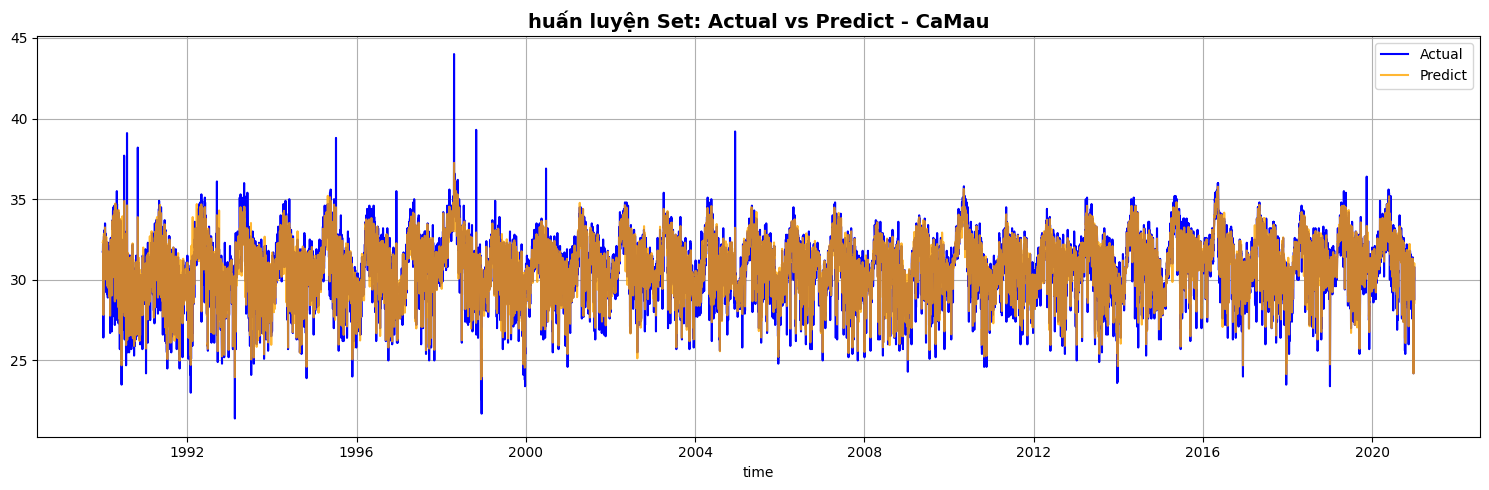

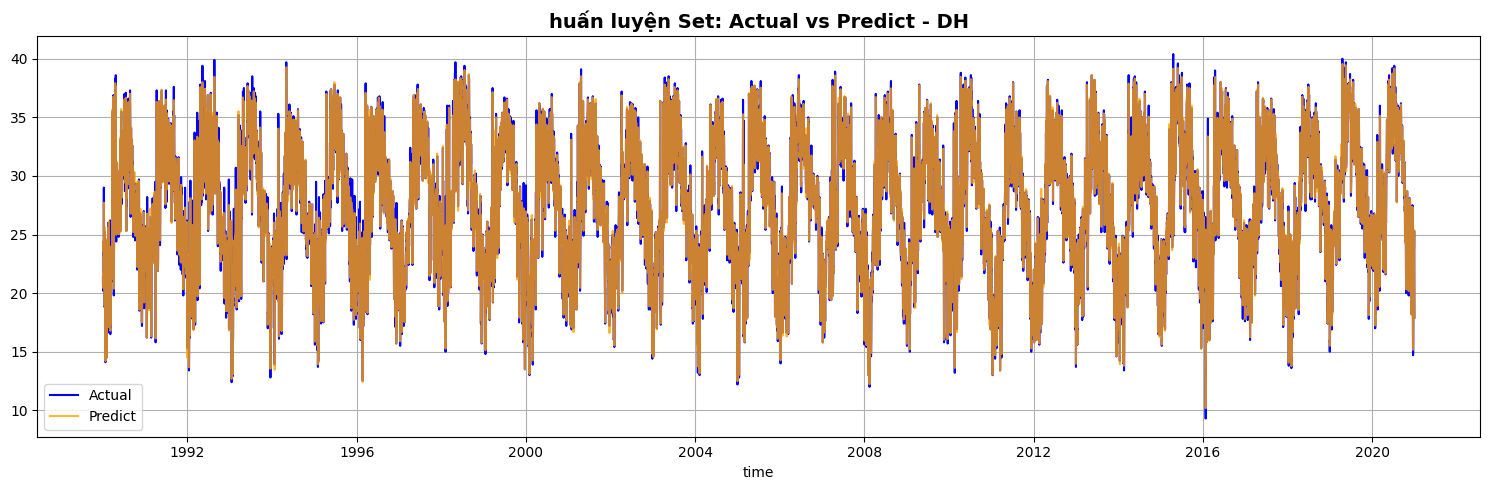

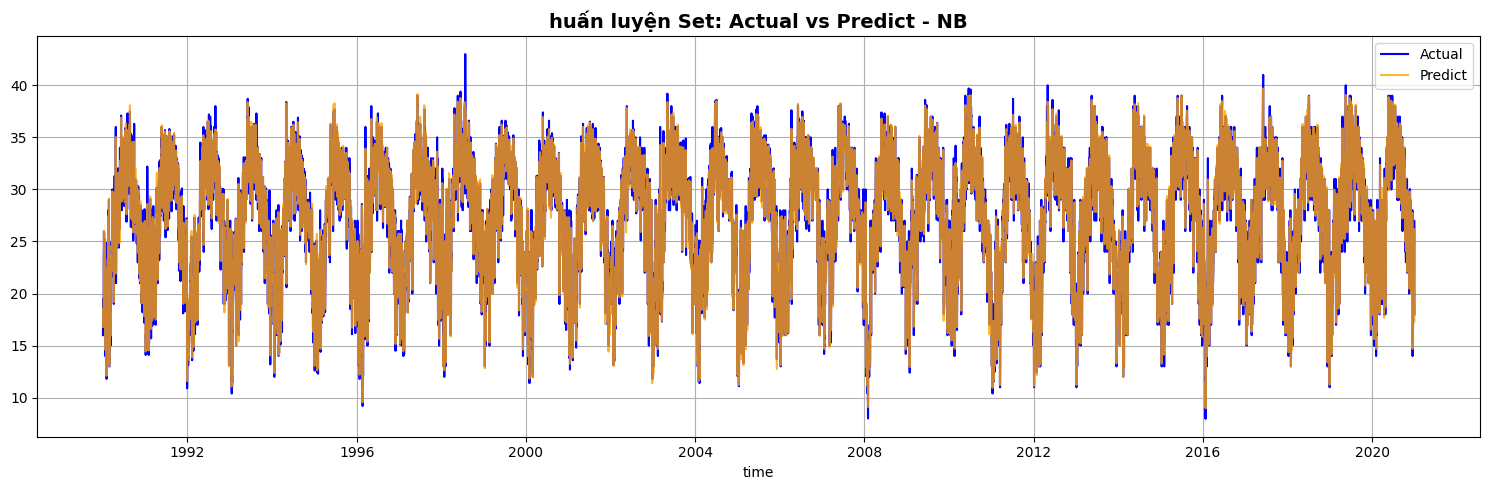

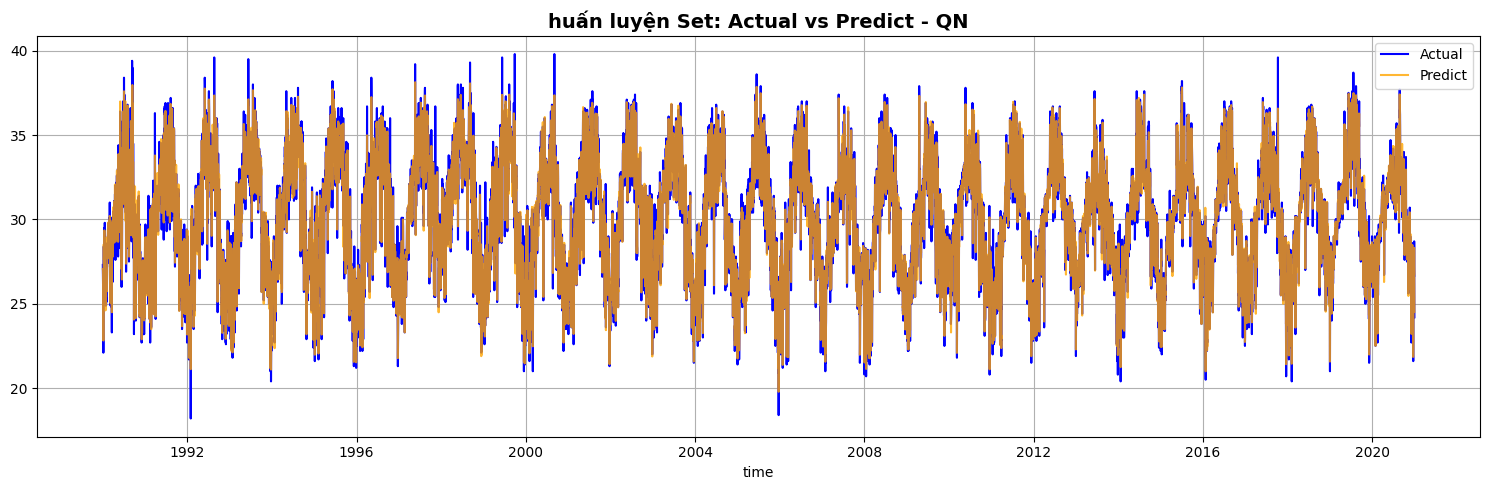

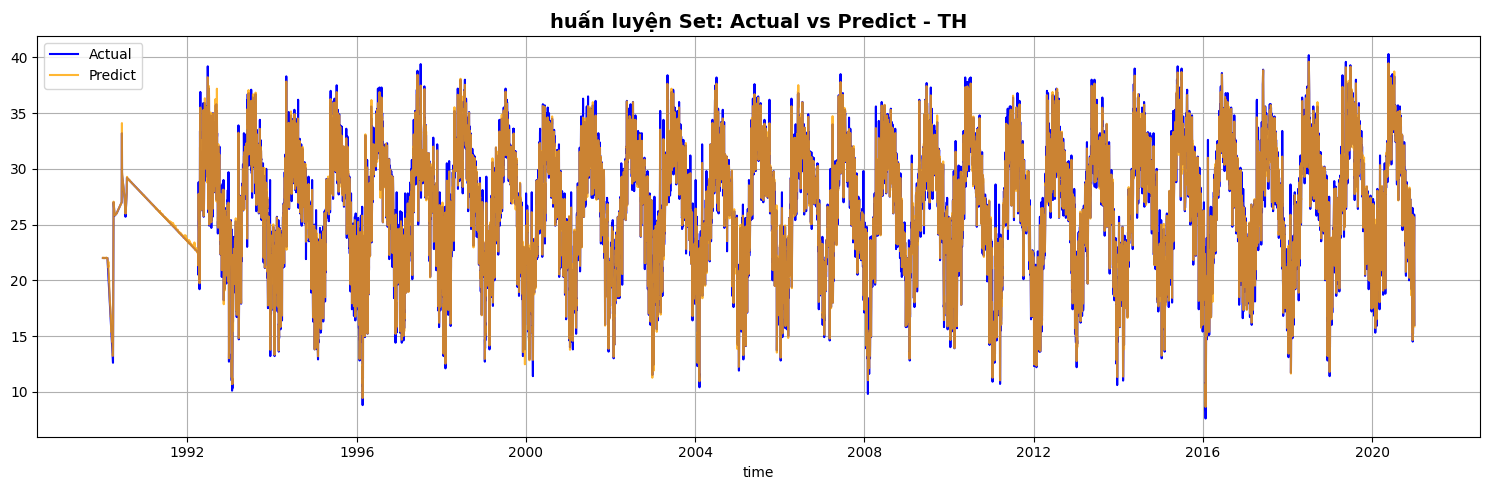

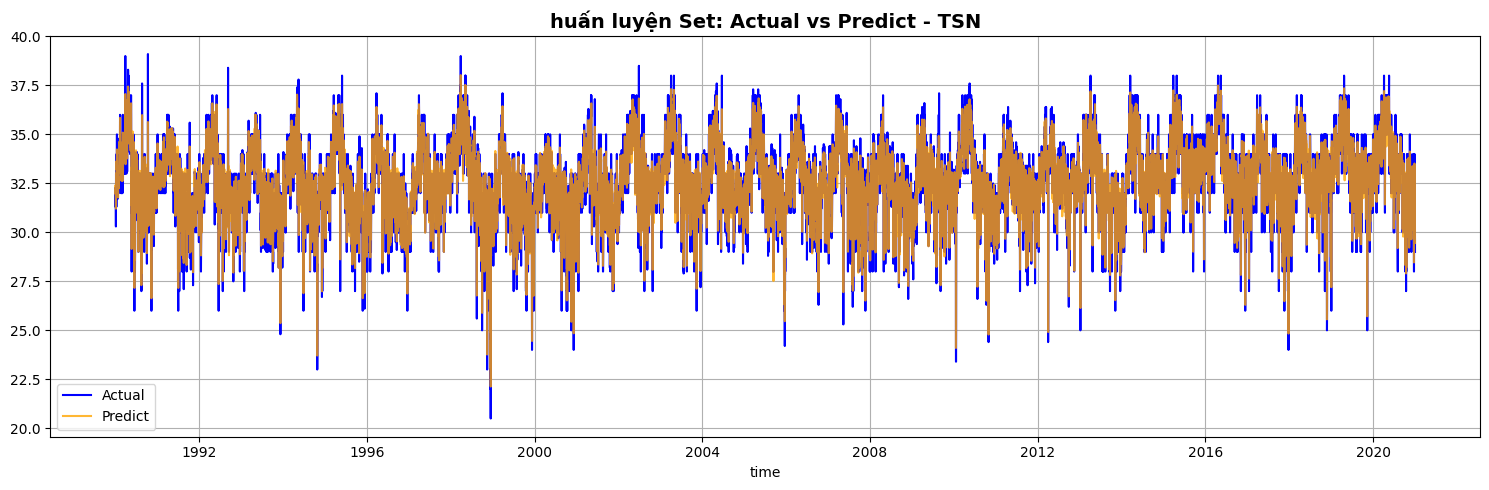

In [37]:
import importlib
importlib.reload(plots)
plots.actual_vs_predict_line_plot(station         = station,
                                  target          = "TEMP_max",
                                  y_train_encoded = y_train_encoded,
                                  station_fit     = station_fit,
                                  scaler_y        = scaler_y,
                                  set_name        = "huấn luyện")

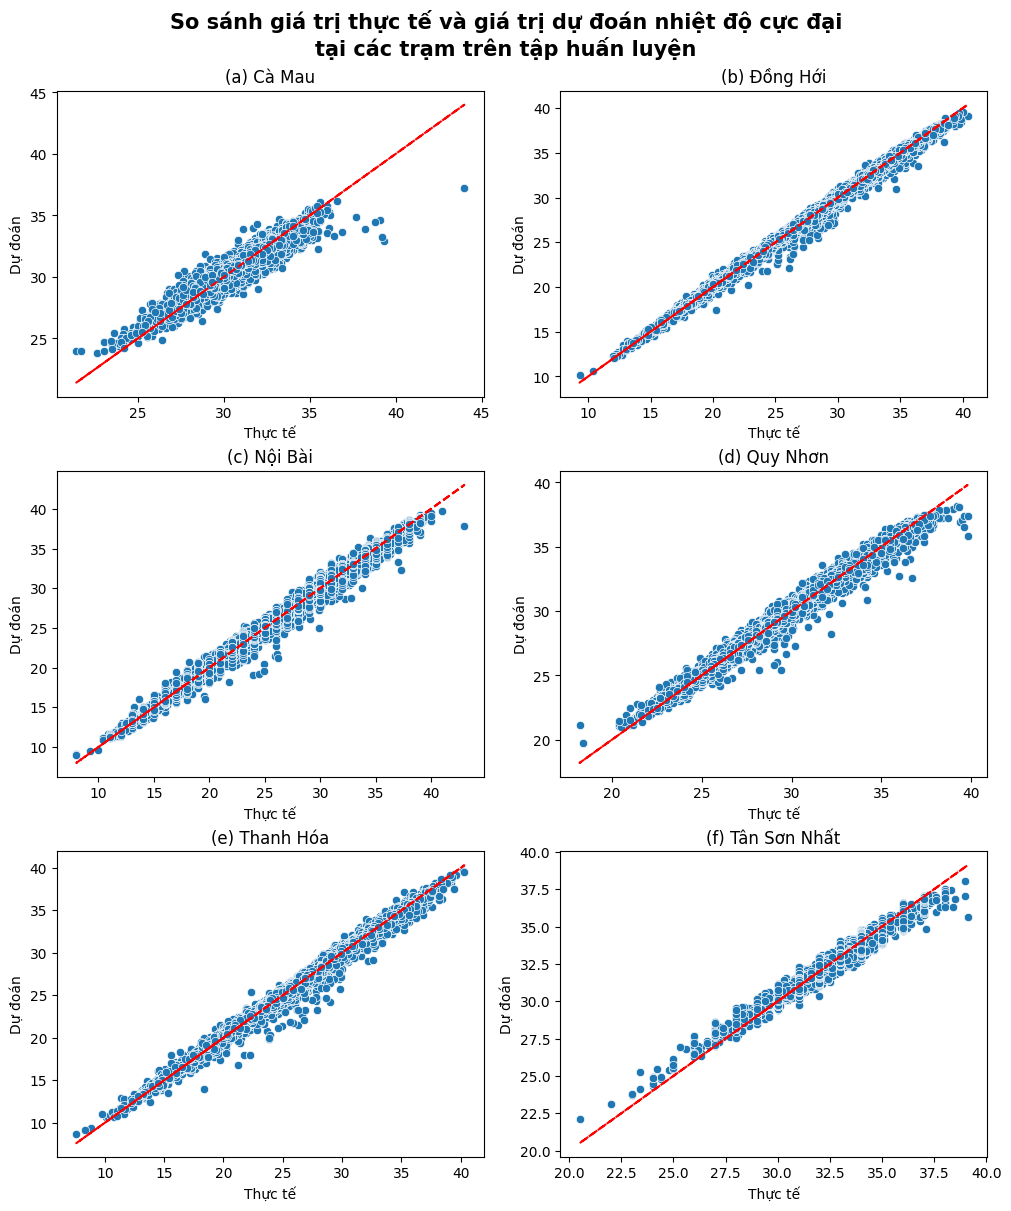

In [38]:
import importlib
importlib.reload(plots)
plots.actual_vs_predict_scatter_plot(station         = station,
                                     src_name        = src_name,
                                     target          = "TEMP_max",
                                     y_train_encoded = y_train_encoded,
                                     station_fit     = station_fit,
                                     scaler_y        = scaler_y,
                                     set_name        = "huấn luyện")

true_valid vs valid

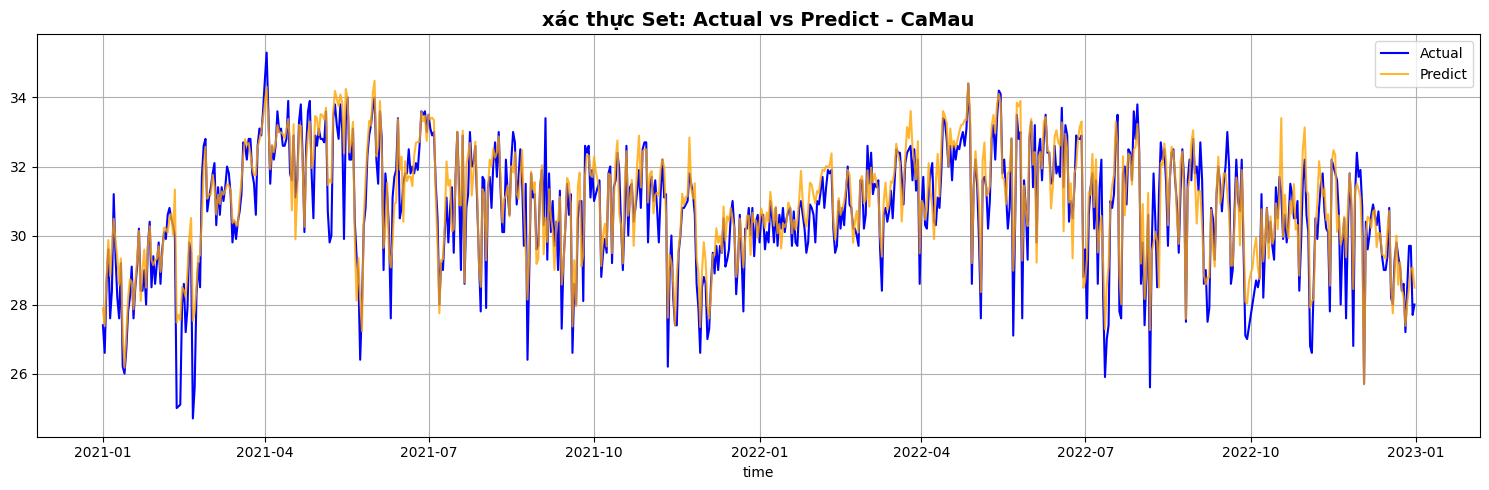

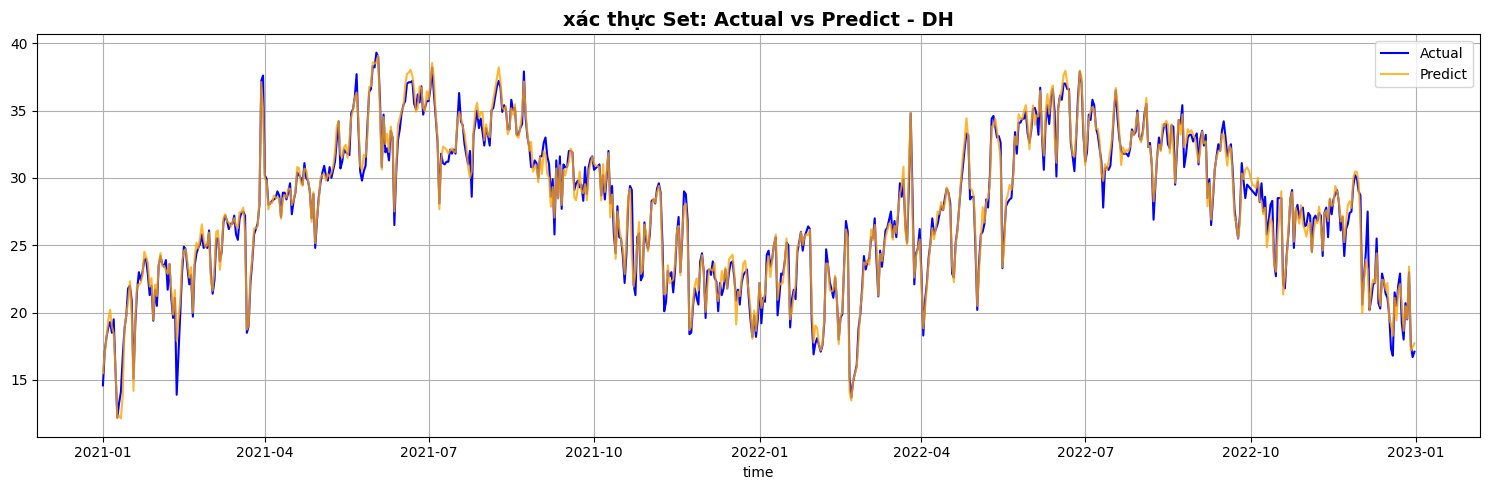

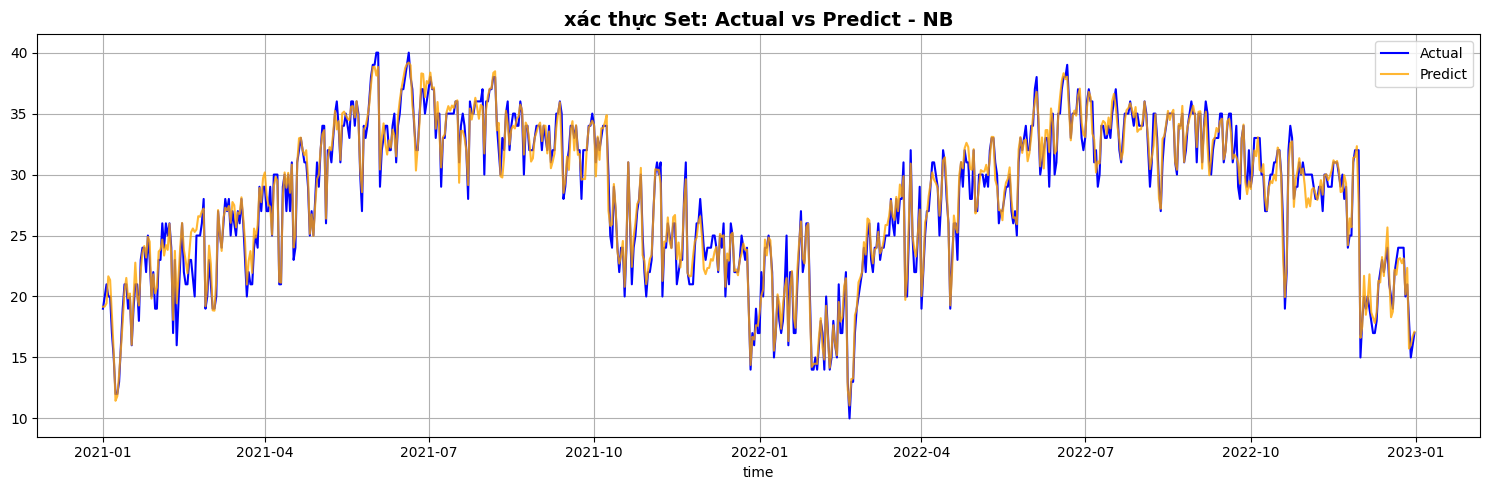

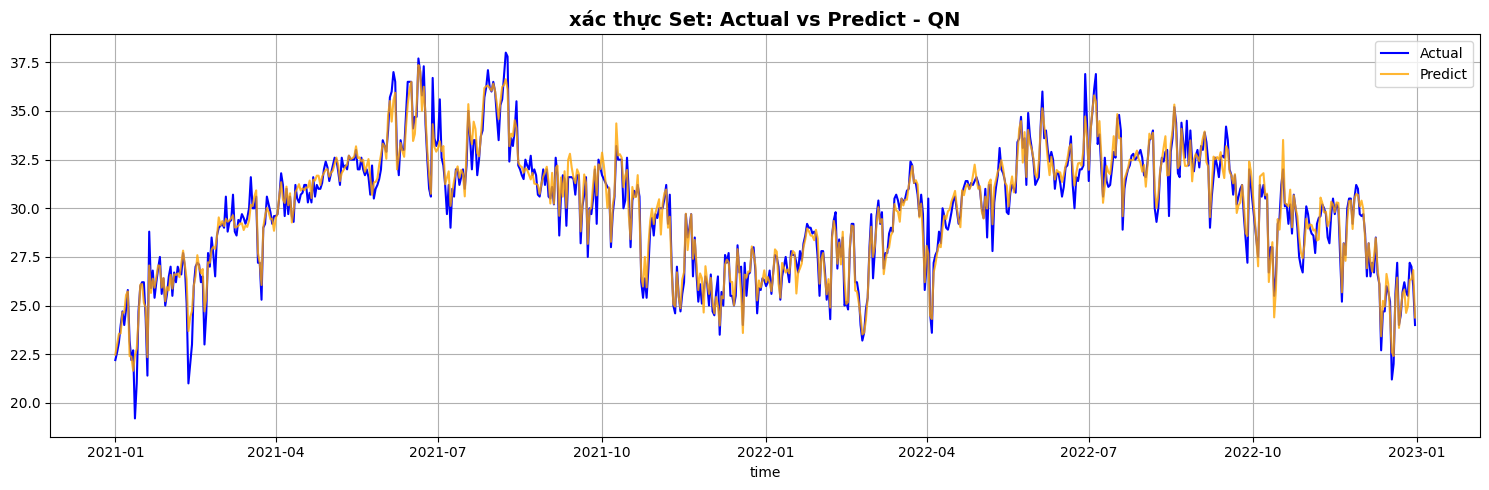

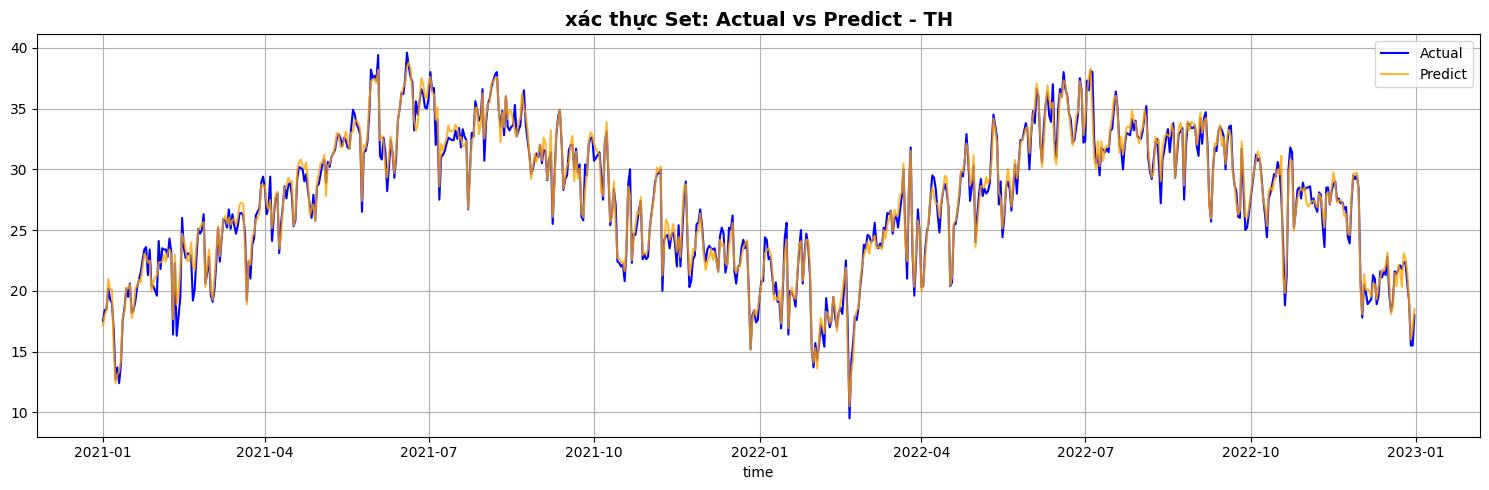

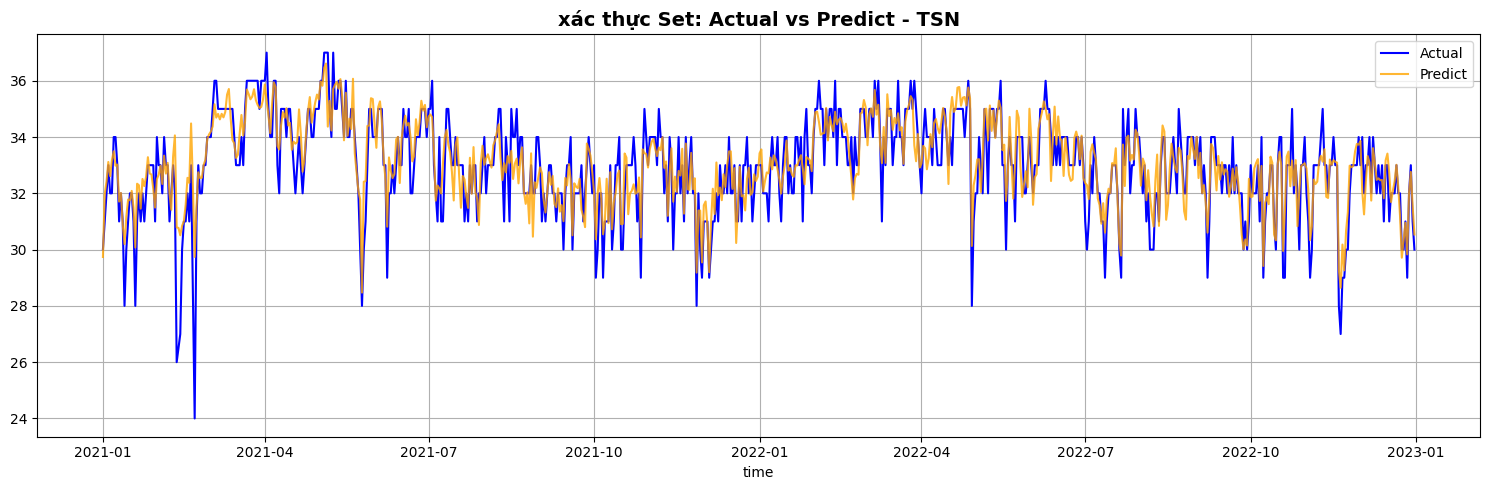

In [39]:
import importlib
importlib.reload(plots)
plots.actual_vs_predict_line_plot(station         = station,
                                  target          = "TEMP_max",
                                  y_train_encoded = y_valid_encoded,
                                  station_fit     = station_valid,
                                  scaler_y        = scaler_y,
                                  set_name        = "xác thực")

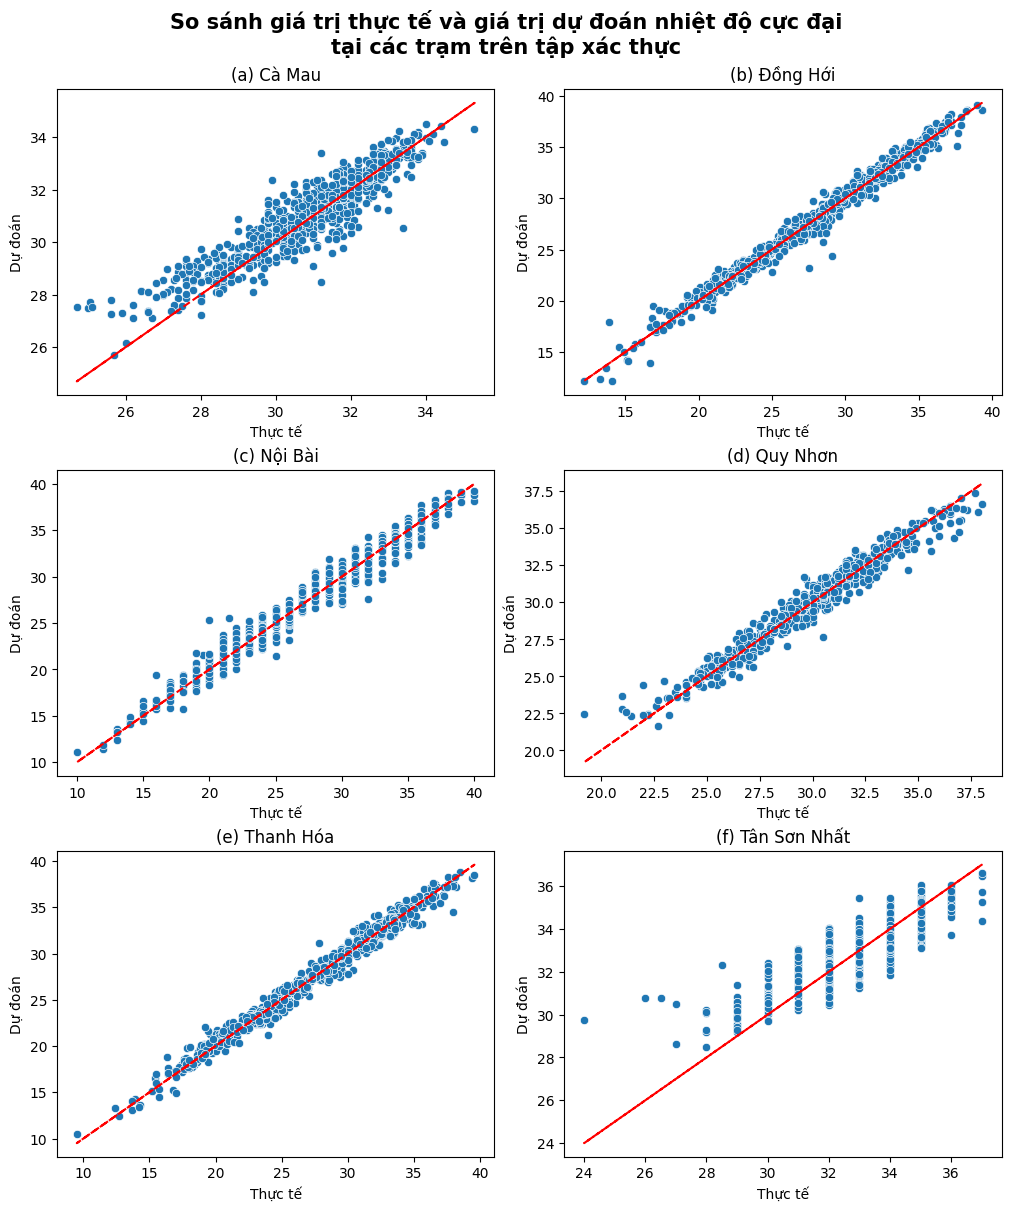

In [40]:
import importlib
importlib.reload(plots)
plots.actual_vs_predict_scatter_plot(station         = station,
                                     src_name        = src_name,
                                     target          = "TEMP_max",
                                     y_train_encoded = y_valid_encoded,
                                     station_fit     = station_valid,
                                     scaler_y        = scaler_y,
                                     set_name        = "xác thực")

true_pred vs pred

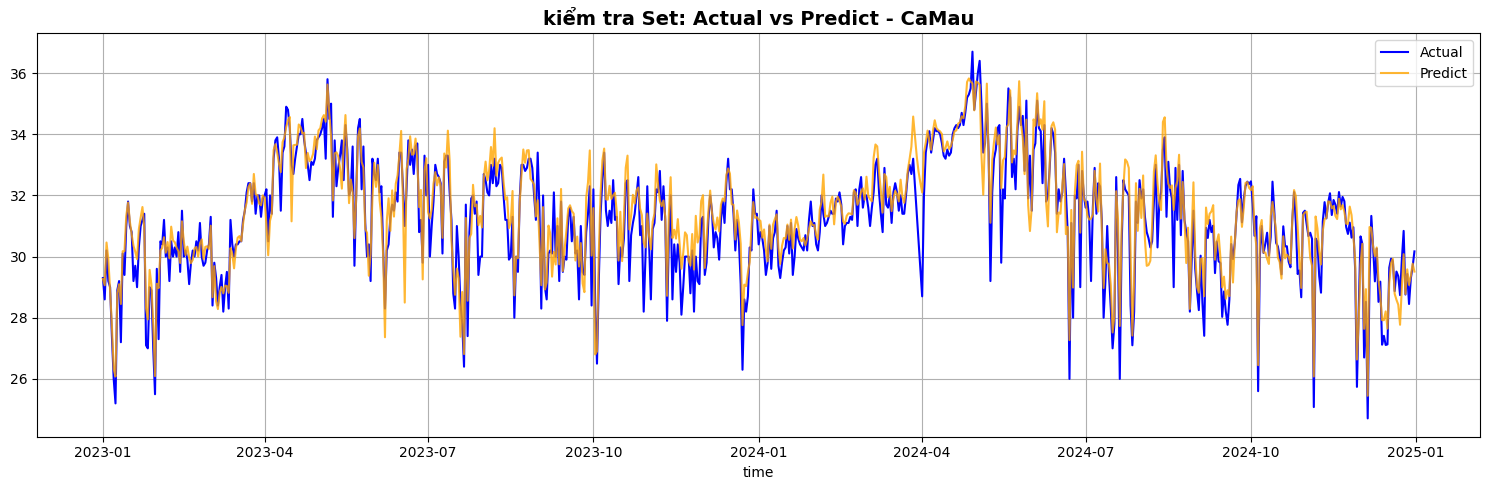

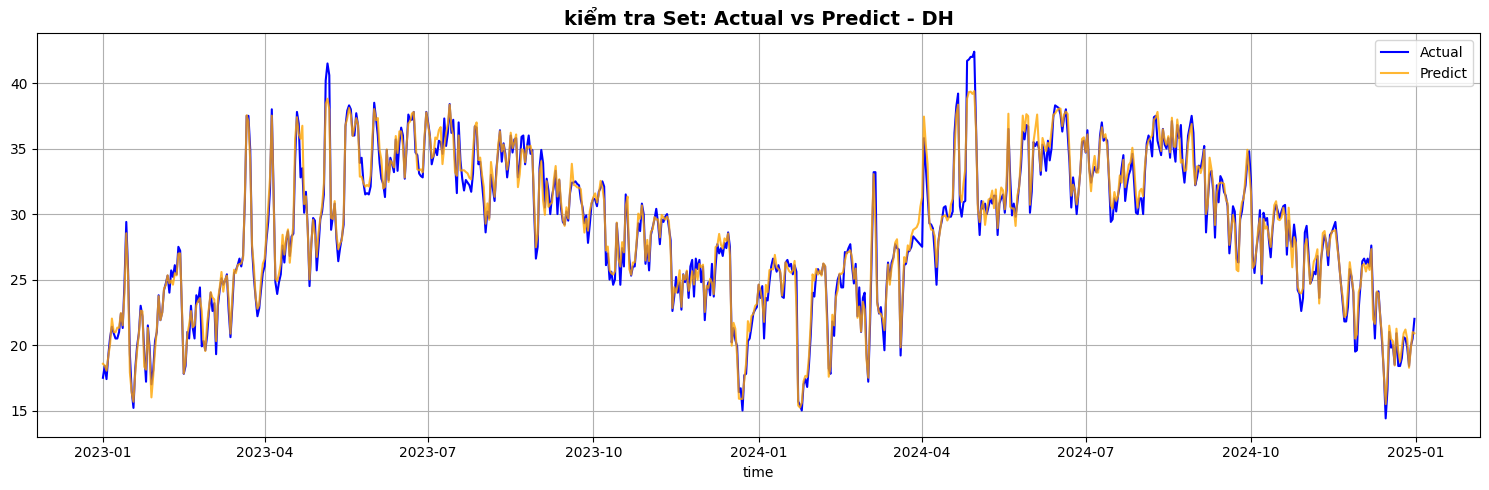

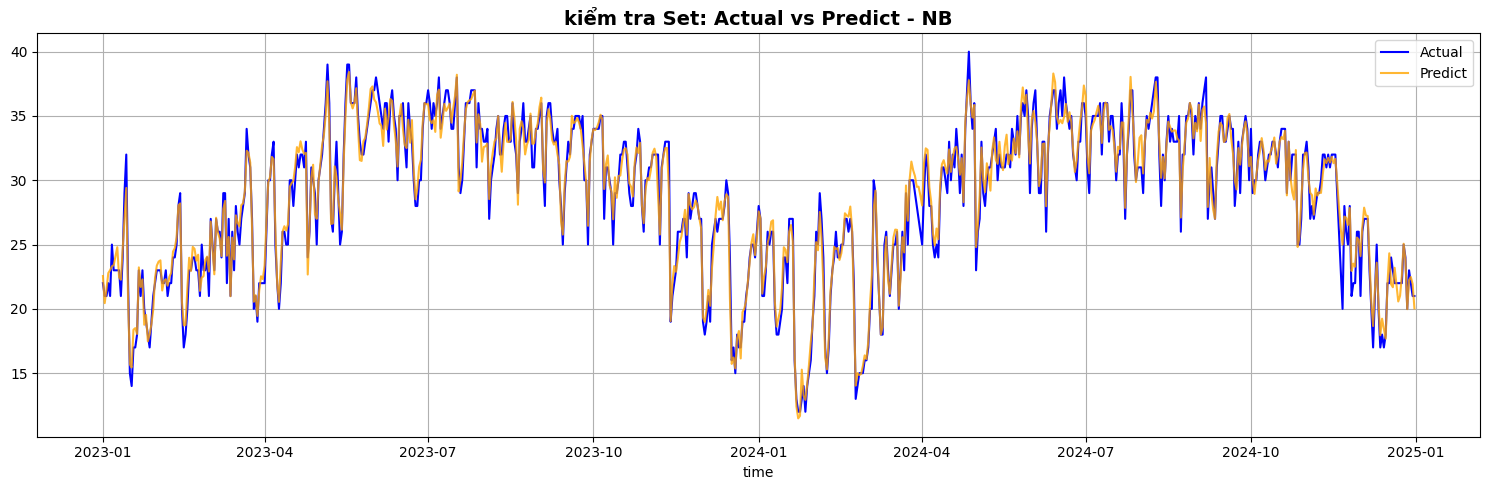

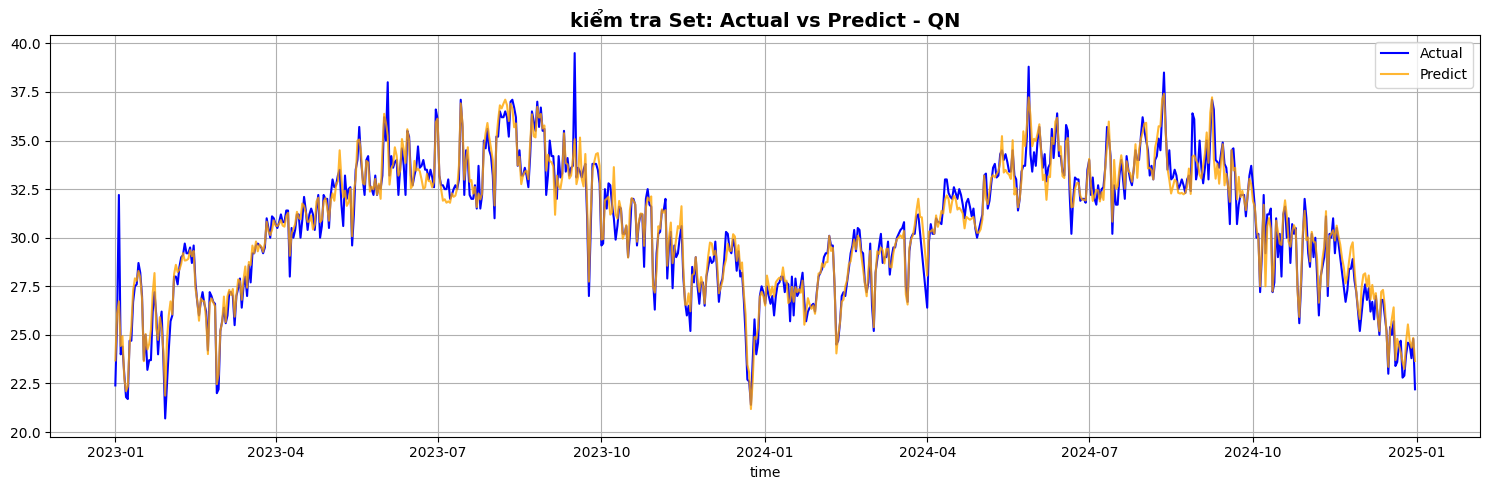

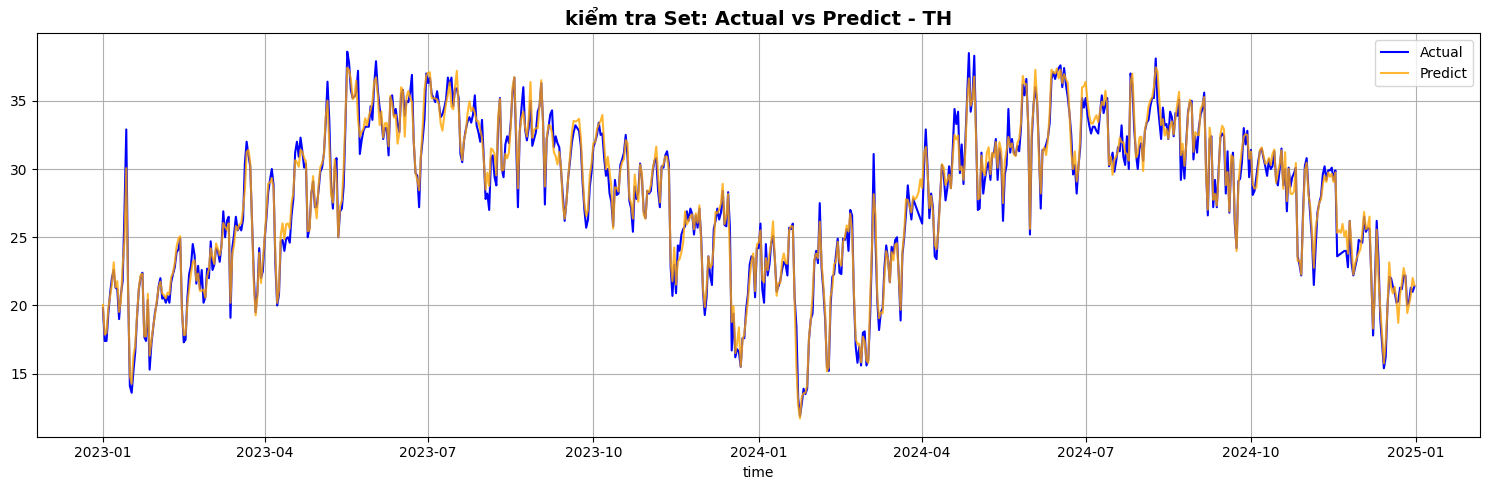

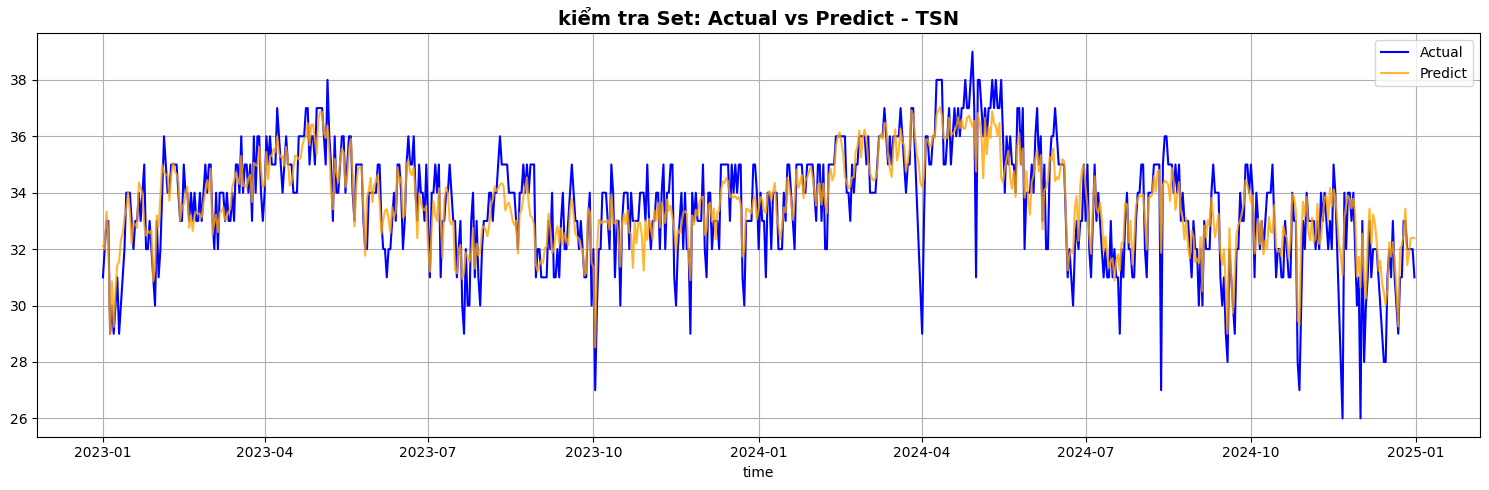

In [41]:
import importlib
importlib.reload(plots)
plots.actual_vs_predict_line_plot(station         = station,
                                  target          = "TEMP_max",
                                  y_train_encoded = y_test_encoded,
                                  station_fit     = station_pred,
                                  scaler_y        = scaler_y,
                                  set_name        = "kiểm tra")

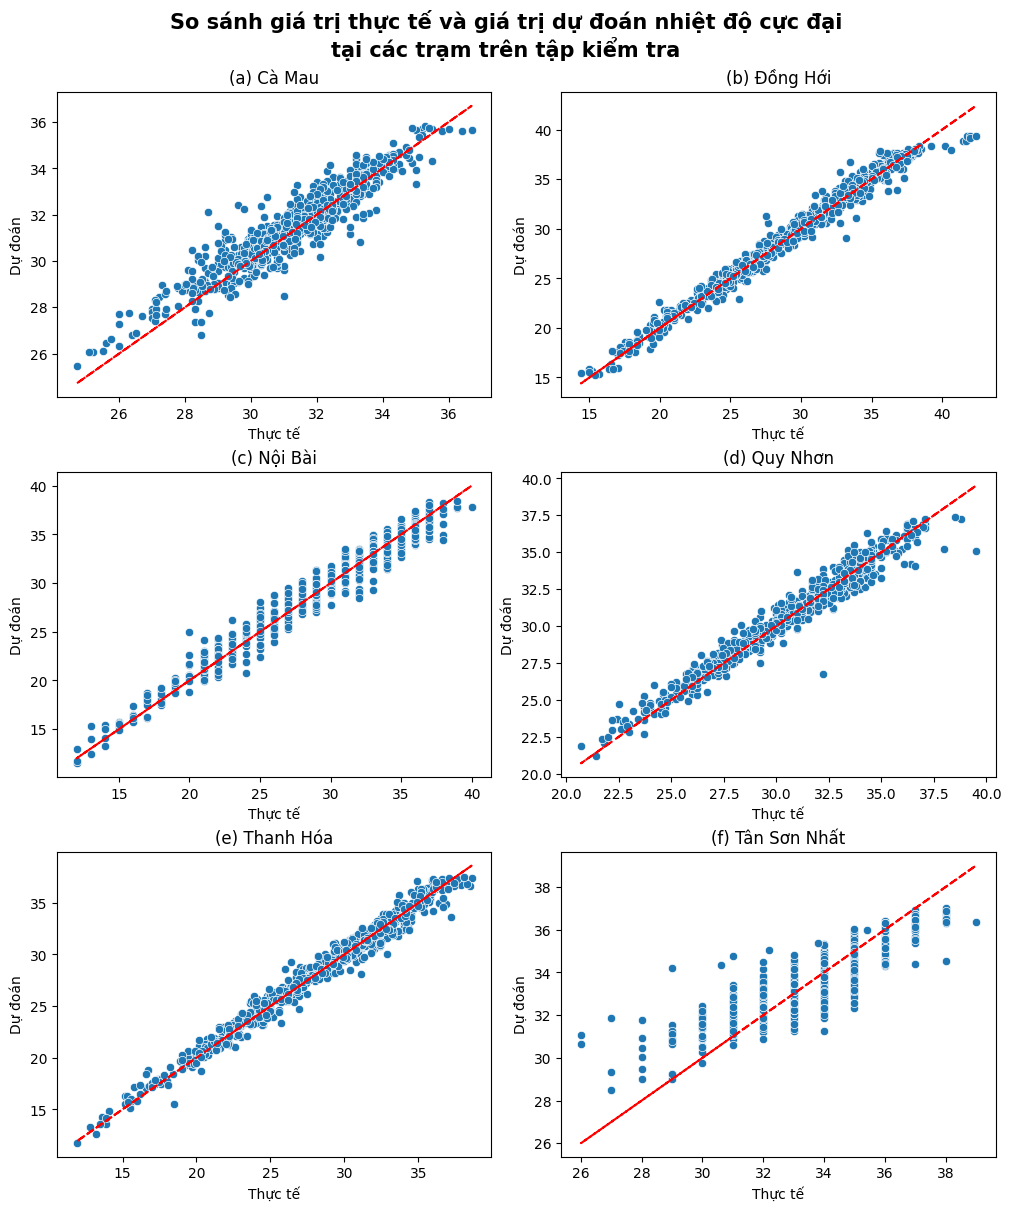

In [42]:
import importlib
importlib.reload(plots)
plots.actual_vs_predict_scatter_plot(station         = station,
                                     src_name        = src_name,
                                     target          = "TEMP_max",
                                     y_train_encoded = y_test_encoded,
                                     station_fit     = station_pred,
                                     scaler_y        = scaler_y,
                                     set_name        = "kiểm tra")

##### <span style="color:tomato">Metrics score</span>

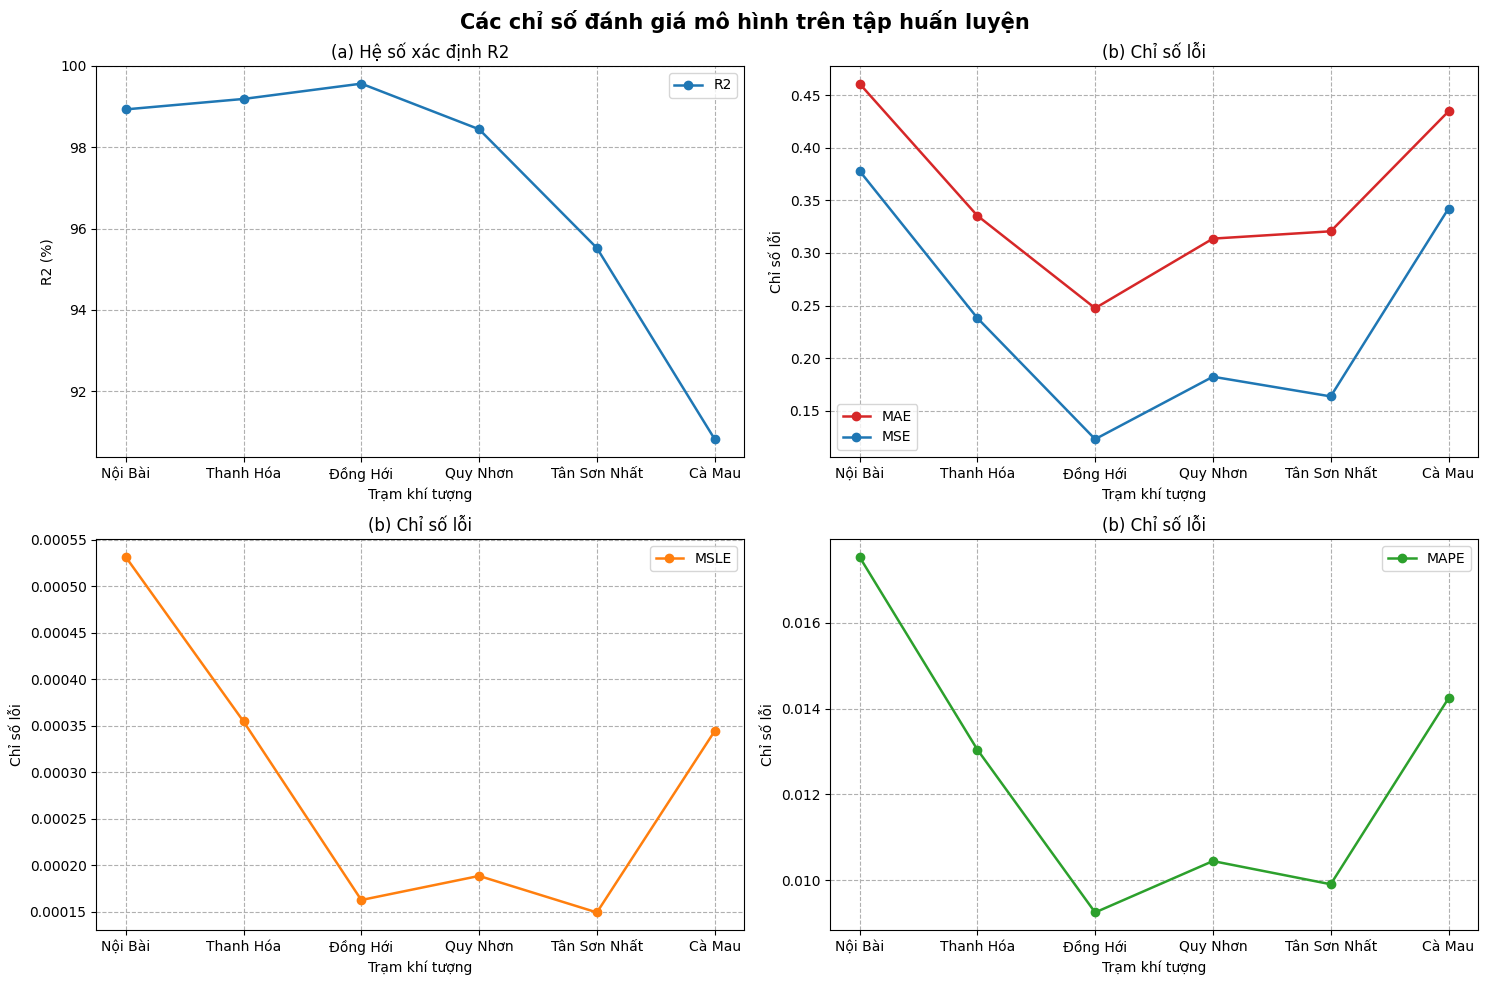

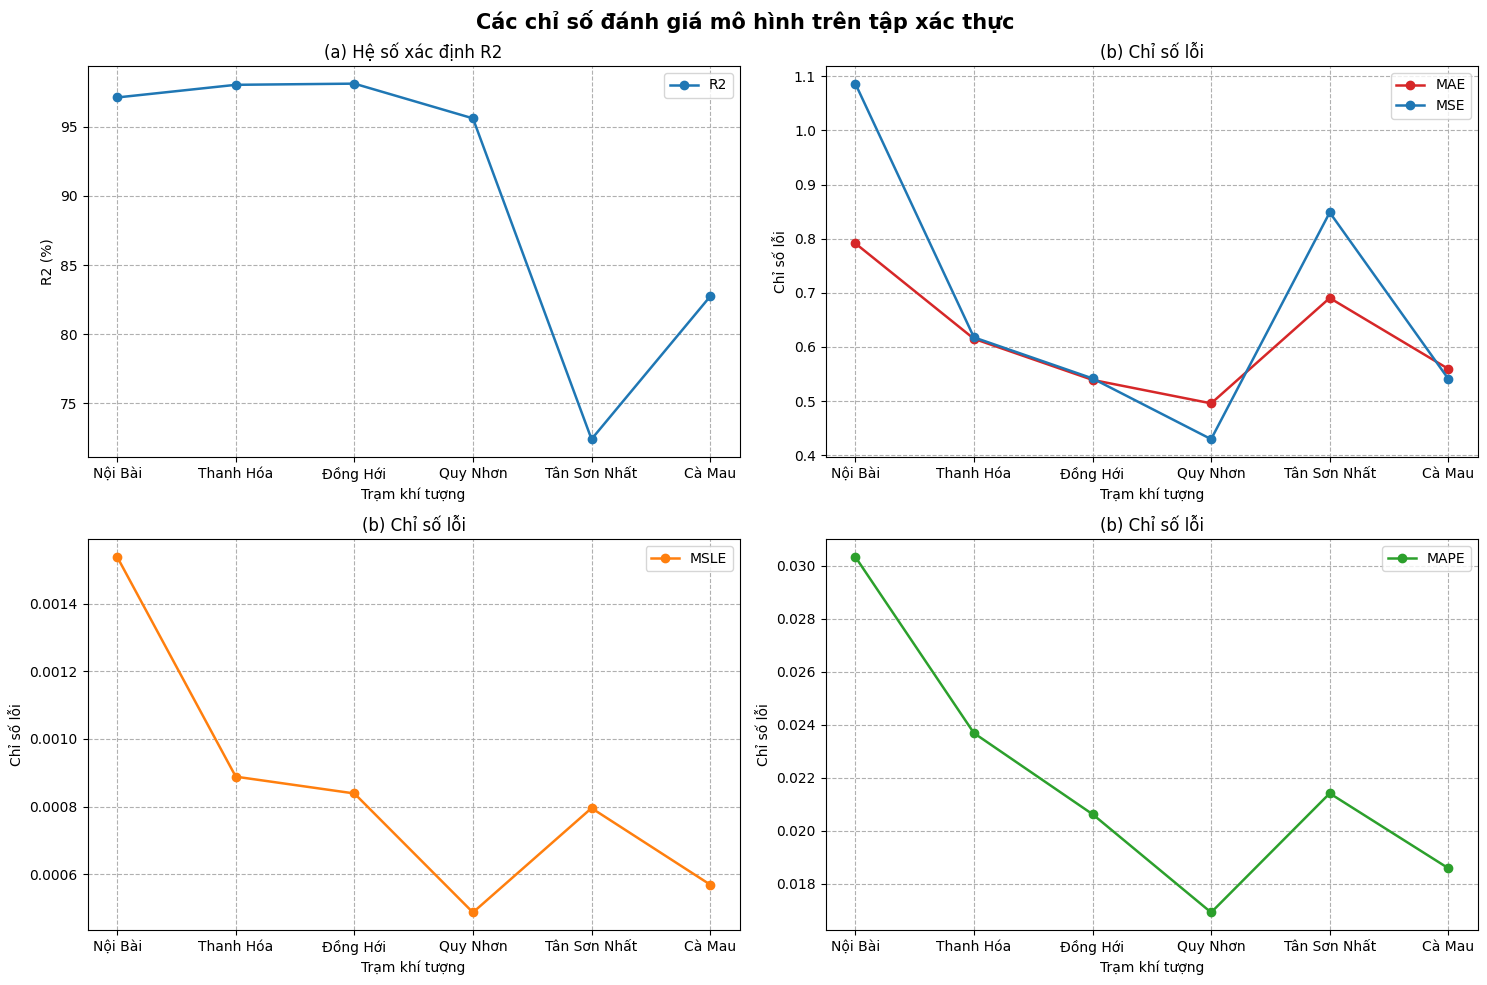

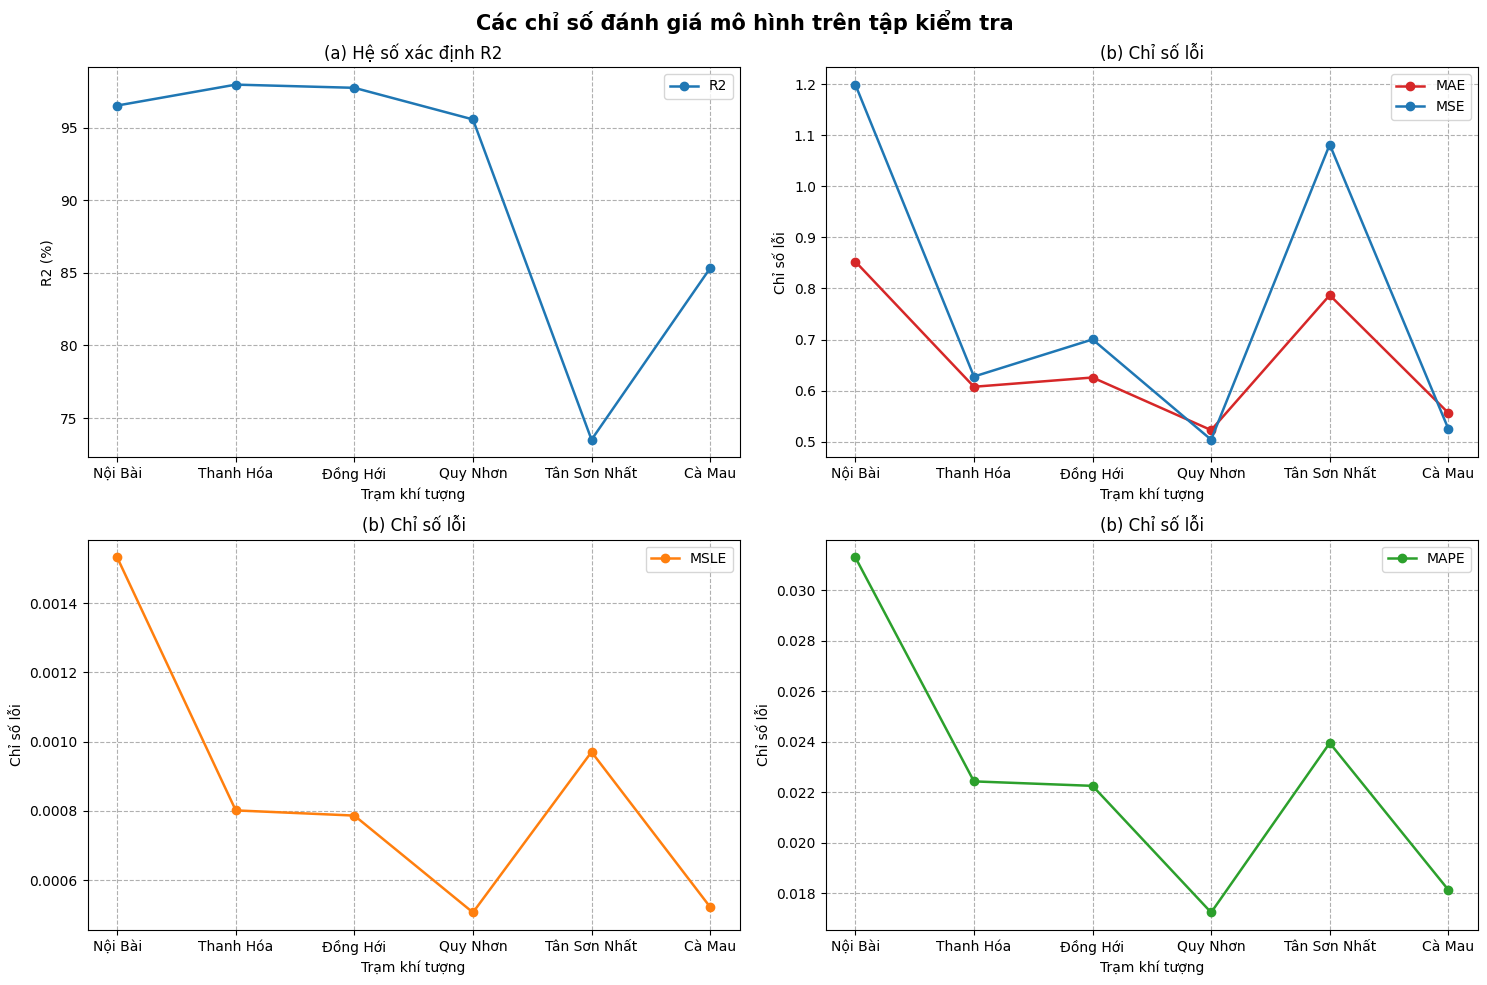

In [43]:
import importlib
importlib.reload(plots)
plots.plot_metrics_in_all_station(station       = station_sorted, 
                                  station_names = src_name,
                                  metrics_dict  = metrics,
                                  datasets      = dict({
                                                        'train': 'huấn luyện',
                                                        'valid': 'xác thực',
                                                        'test' : 'kiểm tra'
                                                        }),
                                  metric_names  = list([
                                                        'R2', 
                                                        'MAE', 
                                                        'MSE', 
                                                        'MSLE', 
                                                        'MAPE'
                                                        ]),
                                  display       = True)

##### <span style="color:tomato">Feature Importance</span>

<a href="https://www.youtube.com/watch?v=WbH-XZjCq8k">Find Most Important Features For Machine Learning in Python</a>

C:\Users\trand\AppData\Local\Temp\ipykernel_17356\2321537798.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


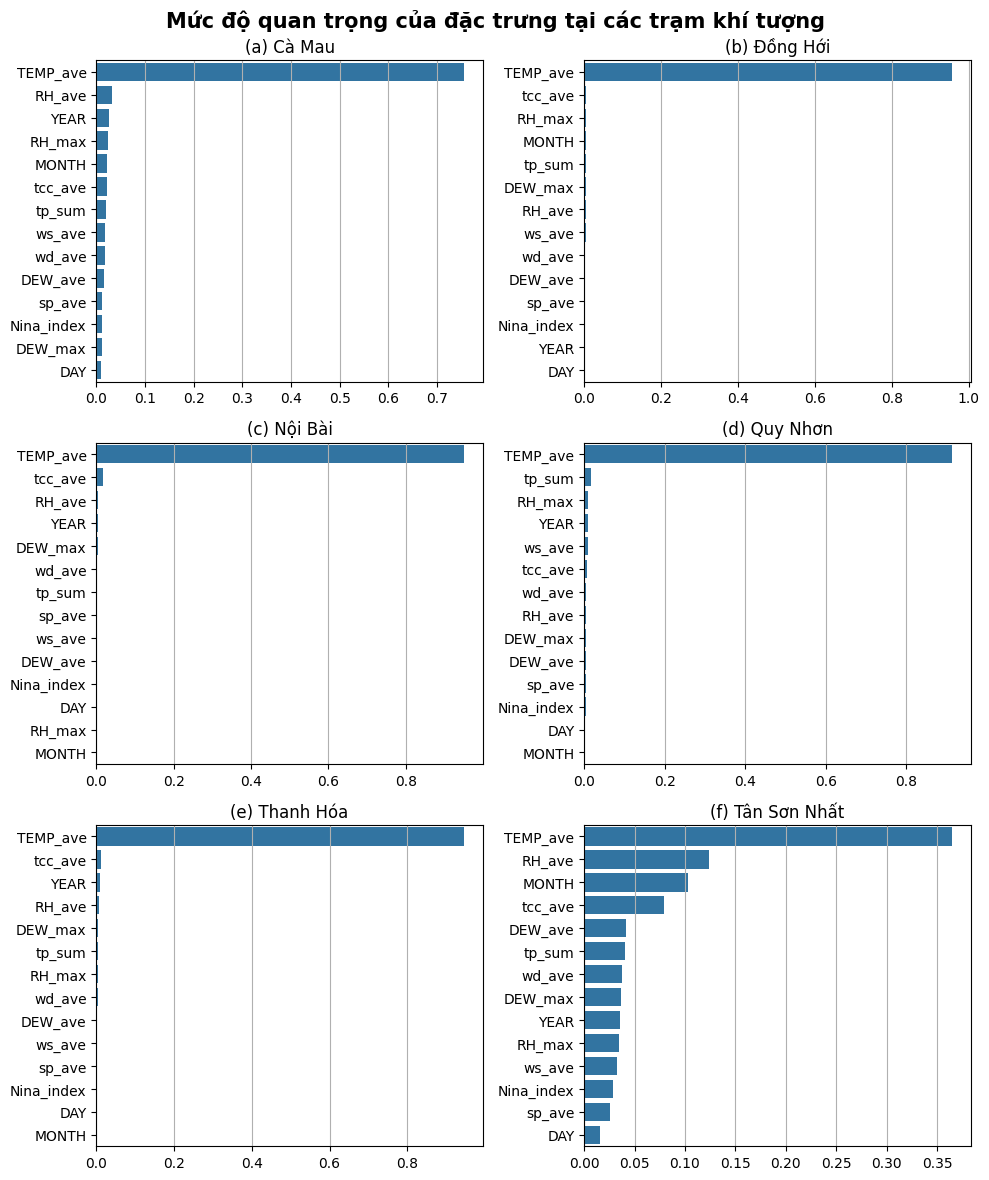

In [44]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 2  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols              = ncols, 
                       nrows              = nrows, 
                       figsize            = (5*ncols, 4*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

count = list(["a", "b", "c", "d", "e", "f"])
for i, name in enumerate(station.keys(), 0):
    # Concat train và test data cho trạm này
    train_data = pd.concat([X_train_encoded[name], X_test_encoded[name]], axis=0)
    
    # Tạo dictionary feature importance
    fi = dict({k: v for k,v in sorted(zip(train_data[feature_col].columns,
                                          reg_model[name].feature_importances_),
                                      key     = lambda x : x[1],
                                      reverse = True)})
    
    # Plot
    sns.barplot(fi, orient='h', ax=ax[i])
    ax[i].grid(True, axis='x')
    ax[i].set_title(f"({count[i]}) {src_name[name]}")

plt.suptitle("Mức độ quan trọng của đặc trưng tại các trạm khí tượng", 
             fontsize   = 15, 
             fontweight = 'bold', 
             ha         = 'center')
plt.tight_layout()
plt.show()

#### <span style="color:green">6.4. Interpretation of performance</span>

Technical

<a href="https://www.markovml.com/blog/lime-vs-shap#">LIME vs SHAP: A Comparative Analysis of Interpretability Tools</a>

<a href="https://www.youtube.com/watch?v=Vfnv1_bBqNg&t=570s">SHAP Values: An Overview
</a>

Code

<a href="https://www.youtube.com/watch?v=zyXapWWWGG4&list=WL&index=31">Explain Machine Learning Models with SHAP in Python</a>

<a href="https://www.youtube.com/watch?v=CV9FTCvQ32Q&list=WL&index=17">Data Visualization with Python: Lime and SHAP Libraries</a>

<a href="https://machinelearningmastery.com/a-gentle-introduction-to-shap-for-tree-based-models/">A Gentle Introduction to SHAP for Tree-Based Models</a>

<a href="https://apxml.com/posts/lime-vs-shap-difference-interpretability?ref=labelvisor.com">LIME vs SHAP: What's the Difference for Model Interpretability?</a>

<a href="https://www.datacamp.com/tutorial/explainable-ai-understanding-and-trusting-machine-learning-models">Explainable AI - Understanding and Trusting Machine Learning Models</a>

<a href="https://arxiv.org/html/2305.02012v3">A Perspective on Explainable Artificial Intelligence Methods: SHAP and LIME</a>

<a href="https://www.mdpi.com/2076-3417/15/13/7329">Explainable AI for Forensic Analysis: A Comparative Study of SHAP and LIME in Intrusion Detection Models</a>

##### <span style="color:tomato">Load Checkpoint</span>

In [45]:
shap_values_fit    = dict()
shap_values_valid  = dict()
shap_values_pred   = dict()

for name in station.keys():
    shap_values_fit[name]   = joblib.load(model_path.replace("trained_models","checkpoints") + f"shap_values_fit_{name}.pkl")
    shap_values_valid[name] = joblib.load(model_path.replace("trained_models","checkpoints") + f"shap_values_valid_{name}.pkl")
    shap_values_pred[name]  = joblib.load(model_path.replace("trained_models","checkpoints") + f"shap_values_pred_{name}.pkl")

##### <span style="color:tomato">SHAP <~> SHapley Additive exPlanations</span>

In [46]:
explainer = dict()

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    optimize_k = (X_train_encoded[name][feature_col].shape[1] + y_train_encoded[name].shape[1] - 1) * 2

    if model_name == "XGBOOST":
        explainer[name] = shap.KernelExplainer(model = lambda X: reg_model[name].predict(X),
                                               data  = shap.kmeans(X_train_encoded[name][feature_col], optimize_k))
    else:
        explainer[name] = shap.KernelExplainer(model = reg_model[name].predict,
                                               data  = shap.kmeans(X_train_encoded[name][feature_col], optimize_k))

🔸 Trạm: CaMau


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 807 out of 807 | elapsed:    0.0s finished


🔸 Trạm: DH


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


🔸 Trạm: NB


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:    0.1s finished


🔸 Trạm: QN


KeyboardInterrupt: 

true_fit vs fit

In [ ]:
import importlib
importlib.reload(plots)

# Tham số hiển thị
ncols      = 2                       # số cột trong grid
col_width  = 15.0                    # độ rộng mỗi cột (inch)
row_height = 15.0                    # chiều cao tối thiểu mỗi subplot (inch)

plots.shap_summary_plot(station          = station, 
                        src_name         = src_name,
                        shap_vals        = shap_values_fit, 
                        features_to_plot = X_train_encoded,
                        feature_col      = feature_col,
                        set_name         = "huấn luyện",
                        col_width        = col_width,
                        row_height       = row_height,
                        ncols            = ncols)

true_valid vs valid

In [ ]:
plots.shap_summary_plot(station          = station,
                        src_name         = src_name,
                        shap_vals        = shap_values_valid, 
                        features_to_plot = X_valid_encoded,
                        feature_col      = feature_col,
                        set_name         = "xác thực",
                        col_width        = col_width,
                        row_height       = row_height,
                        ncols            = ncols)

true_pred vs pred

In [ ]:
plots.shap_summary_plot(station          = station,
                        src_name         = src_name,
                        shap_vals        = shap_values_pred, 
                        features_to_plot = X_test_encoded,
                        feature_col      = feature_col,
                        set_name         = "kiểm tra",
                        col_width        = col_width,
                        row_height       = row_height,
                        ncols            = ncols)

testing

In [ ]:
# def plot_shap_explaination(x_train_test, y_train_test, feature_col, shap_values, scaler, explainer, station, station_fit):
#     for name in station.keys():
#         # PLOT 1
#         print(f"🔸 Trạm: {name}")
#         sample_idx = random.randint(0,len(x_train_test[name]))
#         x_data     = x_train_test[name].iloc[[sample_idx]]
#         x          = scaler["x"][name].inverse_transform(x_data[feature_col])
#         y_data     = y_train_test[name].iloc[[sample_idx]]
#         y          = scaler["y"][name].inverse_transform(y_data["TEMP_max"][0])

#         # Select an interesting prediction to explain
#         sample_prediction = station_fit[name].iloc[sample_idx][0]
#         actual_value      = y

#         print(f"Analyzing prediction for {name} index {x_data.index[0]}:")
#         print(f"Predicted values  : {sample_prediction:,.2f}°C")
#         print(f"Actual values     : {actual_value:,.2f}°C")
#         print(f"Prediction error  : {abs(sample_prediction - actual_value):,.2f}°C")

#         # Create SHAP waterfall plot
#         plt.figure(figsize=(15, 6))
#         shap.waterfall_plot(
#             shap.Explanation(
#                 values        = shap_values[name][sample_idx], 
#                 base_values   = explainer[name].expected_value, 
#                 data          = x[0],
#                 feature_names = x_data[feature_col].columns.tolist()
#             ),
#             max_display = 15,  # Show top 15 contributing features
#             show        = False
#         )
#         plt.title(f'How Our Model Predicts {sample_prediction:,.0f}°C for {name} index {x_data.index[0]}', 
#                   fontsize   = 14, 
#                   fontweight = 'bold', 
#                   pad        = 20)
#         plt.tight_layout()
#         plt.show()

#         # PLOT 2
#         # Analyze the feature contributions for our sample house
#         feature_values = x[0]
#         shap_contributions = shap_values[name][sample_idx]

#         # Create a detailed breakdown of contributions
#         feature_breakdown = pd.DataFrame({
#             'Feature'           : x_data[feature_col].columns,
#             'Feature_Value'     : feature_values,
#             'SHAP_Contribution' : shap_contributions,
#             'Impact'            : ['Increases Price' if x > 0 else 'Decreases Price' for x in shap_contributions]
#         }).sort_values('SHAP_Contribution', key=abs, ascending=False)

#         print(f"Top {len(feature_breakdown)} Feature Contributions to This Prediction:")
#         print("=" * 60)
#         for idx, row in feature_breakdown.iterrows():
#             impact_symbol = "↑" if row['SHAP_Contribution'] > 0 else "↓"
#             print(f"{row['Feature']:23} {impact_symbol} {row['SHAP_Contribution']:8,.2f}°C "
#                   f"(Value: {row['Feature_Value']:.2f})")

#         print(f"\nBase prediction    : {explainer[name].expected_value:,.2f}°C")
#         print(f"Sum of contributions : {shap_contributions.sum():+,.2f}°C")
#         print(f"Final prediction     : {explainer[name].expected_value + shap_contributions.sum():,.2f}°C")
#         print()
        
        
# plot_shap_explaination(x_train_test = X_train_encoded,
#                        y_train_test = y_train_encoded,
#                        feature_col  = feature_col,
#                        station      = station,
#                        station_fit  = station_fit,
#                        shap_values  = shap_values_fit,
#                        explainer    = explainer,
#                        scaler       = {"x" : scaler_x,
#                                        "y" : scaler_y})

#### <span style="color:green">6.5. Comparasion Model</span>

In [ ]:
import importlib
importlib.reload(plots)
plots.comparasion_model(station       = station_order,
                        station_names = src_name,
                        metrics_dict  = all_models_metrics,
                        datasets = dict({
                                          'train': 'huấn luyện',
                                          'valid': 'xác thực',
                                          'test' : 'kiểm tra'
                                        }),                        
                        metric_names  = list([
                                              'R2', 
                                              'MAE', 
                                              'MSE', 
                                              'MSLE', 
                                              'MAPE'
                                              ]),
                        ncols         = 2)

### Vì sao KernelExplainer cho kết quả khác với `model.predict`

Khi sử dụng **`KernelExplainer`** của SHAP với mô hình như **RandomForestRegressor**, kết quả giải thích có thể **lệch** so với giá trị thực tế mà `model.predict` trả về. Nguyên nhân chính bao gồm:

1. **Bản chất xấp xỉ (approximation) của Kernel SHAP**  
   - Kernel SHAP là một phương pháp "mô phỏng" giá trị Shapley bằng cách sinh ra các mẫu dữ liệu giả (coalitions) rồi huấn luyện một mô hình tuyến tính xấp xỉ để tính độ quan trọng đặc trưng.  
   - Do dùng sampling + approximation nên kết quả giải thích thường không khớp tuyệt đối với `model.predict`, mà chỉ gần đúng.

2. **Tính chất ngẫu nhiên (randomness) trong quá trình lấy mẫu**  
   - Kernel SHAP không duyệt toàn bộ không gian tập con đặc trưng (2^n subsets) mà chỉ chọn một số lượng hữu hạn mẫu.  
   - Nếu số lượng mẫu ít, sai số xấp xỉ càng lớn, dẫn đến lệch nhiều so với `model.predict`.

3. **Khác biệt giữa expectation baseline và output thực tế**  
   - SHAP tính toán giá trị dựa trên **chênh lệch so với kỳ vọng của mô hình** (expected value), không phải trực tiếp bằng output raw của mô hình.  
   - Do đó, tổng (expected value + tổng SHAP values) có thể hơi lệch với `model.predict` do sai số tính toán.

4. **Mô hình phi tuyến (RandomForest, XGBoost, Neural Net, …)**  
   - Với các mô hình phi tuyến mạnh, việc xấp xỉ bằng một mô hình tuyến tính cục bộ như Kernel SHAP sẽ khó chính xác tuyệt đối, nên kết quả giải thích khác so với dự đoán thực tế.

👉 Tóm lại:  
KernelExplainer không đảm bảo **giải thích khớp 100%** với `model.predict`, vì nó là phương pháp **xấp xỉ dựa trên sampling và baseline expectation**. Để giảm sai số, cần:
- Tăng số lượng mẫu (`nsamples`).
- Sử dụng explainer chuyên biệt (ví dụ `TreeExplainer` cho RandomForest, XGBoost).


<a href="https://www.youtube.com/watch?v=ZMB6TwQ6Vuo&list=WL&index=32">Machine Learning Model Explainability with LIME in Python</a>

### <span style="color:orange">7. Conclusion</span>